##### 환경
- local(big_stats25)에 전진선택법과 후진선택법, 단계적 방법 구현을 위해 mlxtend 패키지 추가 설치하여 사용.

##### 1. 데이터
    - 관측치: 150,000건 / 변수: 11개
    - 목표변수: `SeriousDlqin2yrs` (2년 내 심각 연체 여부)

##### 2. 결측치 처리

| 변수 | 처리 방법 |
|:---|:---:|
| `MonthlyIncome` | 중앙값 대체 |
| `NumberOfDependents` | 최빈값 대체 |

##### 3. 이상치/논리적 모순 처리

| 처리 유형 | 대상 | 방법 |
|:---|:---|:---|
| 삭제 | `age` < 18 or > 100 | 행 삭제 |
| 삭제 | 연체 특수코드 (96, 98) | 행 삭제 |
| 삭제 | `MonthlyIncome` = 0 & `DebtRatio` > 0 | 행 삭제 |
| 삭제 | `OpenLines` IQR 이상치 | 행 삭제 |
| 대체 | `RevolvingUtilization` > 1 | 1로 대체 |
| 대체 | `OpenLines` = 0 & `RevolvingUtilization` > 0 | 0으로 대체 |


##### 4. 최종 모델 해석 및 시사점 (Interpretation & Insights)

> 모든 변수는 평균 중심화(mean-centering)가 적용되어 있어, 1차항 계수는 평균에서의 한계효과를 나타낸다.  
> 2차항이 있는 변수의 경우, 1차항과 2차항을 함께 고려하여 해석한다.

- 4.1. 주요 변수 해석 (2차항 포함 변수는 통합 해석)

A. 1차항 + 2차항이 있는 변수 (비선형 효과)

| 변수 | 1차항 계수 (β₁) | 2차항 계수 (β₂) | 평균에서의 오즈비 | 해석 |
|:---|:---:|:---:|:---:|:---|
| `log_NumberOfTimes90DaysLate` | 2.2464 | -0.5938 | 9.45배 | 90일 연체 증가 시 위험 급증, 그러나 반복될수록 추가 증가폭 둔화 |
| `log_NumberOfTime60-89...` | 1.6747 | -0.6021 | 5.34배 | 60-89일 연체 증가 시 위험 증가, 반복 시 추가 증가폭 둔화 |
| `log_NumberOfTime30-59...` | 1.2710 | -0.2614 | 3.56배 | 30-59일 연체 증가 시 위험 증가, 반복 시 소폭 둔화 |
| `log_DebtRatio` | 0.1292 | -0.0278 | 1.14배 | 부채 비율 증가 시 위험 증가, 과도하게 높아지면 증가폭 둔화 |
| `log_MonthlyIncome` | -0.2372 | -0.0450 | 0.79배 | 소득 증가 시 위험 감소, 고소득에서 감소폭 더 커짐 |
| `age_robust` | -0.4052 | -0.0853 | 0.67배 | 나이 증가 시 위험 감소, 고령에서 감소폭 더 커짐 |
| `OpenLines_robust` | 0.0873 | 0.1803 | 1.09배 | 계좌 수 증가 시 위험 소폭 증가, 많아질수록 증가폭 커짐 (U자형) |

> 해석: 연체 관련 변수들은 2차항 계수가 음수(-)이므로 역U자형 효과를 보인다.  
> 처음 연체가 발생할 때 위험도가 급격히 증가하지만, 연체 횟수가 많아질수록 추가적인 위험 증가폭은 둔화된다.  

B. 2차항만 있는 변수 (1차항 없음)

| 변수 | 계수 | 오즈비 | 해석 |
|:---|:---:|:---:|:---|
| `log_NumberRealEstateLoansOrLines_sq` | 0.6055 | 1.83배 | 부동산 대출 건수가 평균에서 멀어질수록 위험 증가 (U자형 효과) |

> 해석: 1차항 없이 2차항만 있으므로, 평균에서 벗어날수록 위험이 증가하는 U자형 패턴이다.

C. 선형 변수 (2차항 없음)

| 순위 | 변수명 | 계수 | 오즈비 | 해석 (1단위 증가 시) |
|:---:|:---|:---:|:---:|:---|
| 1 | `RevolvingUtilization_robust` | 0.8044 | 2.24배 | 한도 사용률 증가 → 위험도 2.2배 증가 |
| 2 | `log_NumberOfDependents` | 0.1128 | 1.12배 | 부양가족 수 증가 → 위험도 12% 증가 |

- 4.2. 부트스트랩 신뢰구간 (1000회 반복)

| 변수명 | 평균 계수 | 표준편차 | 95% 신뢰구간 |
|:---|:---:|:---:|:---|
| `log_NumberOfTimes90DaysLate` | 2.2457 | 0.0859 | (2.0795, 2.4196) |
| `log_NumberOfTime60-89...` | 1.6794 | 0.1121 | (1.4627, 1.8985) |
| `log_NumberOfTime30-59...` | 1.2698 | 0.0580 | (1.1557, 1.3874) |
| `RevolvingUtilization_robust` | 0.8039 | 0.0188 | (0.7682, 0.8419) |
| `log_NumberRealEstate..._sq` | 0.6062 | 0.0410 | (0.5215, 0.6834) |
| `OpenLines_robust_sq` | 0.1802 | 0.0179 | (0.1457, 0.2161) |
| `log_DebtRatio` | 0.1293 | 0.0178 | (0.0955, 0.1634) |
| `log_NumberOfDependents` | 0.1120 | 0.0248 | (0.0620, 0.1582) |
| `OpenLines_robust` | 0.0873 | 0.0216 | (0.0443, 0.1302) |
| `log_DebtRatio_sq` | -0.0278 | 0.0037 | (-0.0348, -0.0205) |
| `log_MonthlyIncome_sq` | -0.0455 | 0.0059 | (-0.0578, -0.0350) |
| `age_robust_sq` | -0.0860 | 0.0314 | (-0.1503, -0.0266) |
| `log_MonthlyIncome` | -0.2376 | 0.0235 | (-0.2821, -0.1936) |
| `log_NumberOfTime30-59..._sq` | -0.2603 | 0.0532 | (-0.3659, -0.1568) |
| `age_robust` | -0.4057 | 0.0224 | (-0.4501, -0.3635) |
| `log_NumberOfTimes90Days..._sq` | -0.5913 | 0.0662 | (-0.7216, -0.4668) |
| `log_NumberOfTime60-89..._sq` | -0.6065 | 0.1069 | (-0.8148, -0.4023) |

##### 5. 정책 제안
1. Hard Knock Out 정책: 90일 이상 연체자 대출 승인 제한/강화 심사
    - 연체 위험을 결정짓는 핵심 요인은 상환 능력이 아닌 연체 경험이다. 
    - 소득이 두 배로 증가하더라도 연체 위험 감소 효과가 미미한 반면, 90일 연체 경험 단 1회만으로도 위험이 9배 이상 급증함을 확인하였다.
    - 첫 번째 연체 발생 시 위험도가 급격히 상승하지만, 반복될 수록 위험 증가폭은 둔화되어 연체 경험 자체가 주요 위험 요인임을 시사한다.
    - 연체 이력이 있는 신청자의 경우, 소득 수준과 무관하게 대출 승인을 제한하거나 별도의 강화된 심사 절차를 적용할 것을 제안한다.
2. 조기 경보 시스템: 첫 연체 방지를 위한 사전 알림·결제 유예 옵션 제공
    - 연체의 한계 효과는 첫 연체 시 가장 크게 나타났다. 
    - 따라서 연체 조짐이 보일 경우, 사전 알림을 통해 고객에게 경고하고, 결제 유예 옵션을 제공하여 첫 연체를 방지하는 전략이 효과적일 것이다.
3. Clean Credit 인센티브: 2년 무연체 시 금리 우대(0.1~0.3%p) 또는 한도 상향(10~20%)
    - 성실한 금융 행동을 장려할 것을 제안한다.
    - 일정 기간 무연체를 유지한 고객에서 혜택을 제공하여 무연체를 유지하는 것에 동기를 부여한다. 


### 1. 파일 임포트

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tools.tools import add_constant

df = pd.read_csv('(big_stat25)_classification_train_public.csv')

In [2]:
print(len(df.columns))
df.head()

11


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# 2. 전처리

### 2.1 결측치 처리
- 결측치가 있는 컬럼을 중앙값과 최빈값으로 대치    
    - NumberOfDependents: 최빈값 대체
        - NumberOfDependents 변수는 부양가족 수를 의미하며, 범주형 변수 이므로 최빈값으로 대체하였다.
    - MonthlyIncome: 중앙값 대체
        - MonthlyIncome 변수는 월 소득을 의미하며, 수치형 변수 이므로 중앙값으로 대체하였다.

In [3]:
# 결측치가 있는 컬럼과 각 컬럼별 결측치 개수
na_counts = df.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)

cols_with_na = na_counts.index.tolist()
print("결측치가 있는 컬럼:", cols_with_na)

# 각 컬럼의 중앙값으로 결측치 대치 (NumberOfDependents는 최빈값)
for col in cols_with_na:
    if col == 'NumberOfDependents':
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"{col} 결측치 대치 완료 (최빈값: {mode_val})")
    else:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col} 결측치 대치 완료 (중앙값: {median_val})")

# 대치 후 결측치 상태 확인
print("\n대치 후 결측치 개수:")
print(df[cols_with_na].isna().sum())

결측치가 있는 컬럼: ['MonthlyIncome', 'NumberOfDependents']
MonthlyIncome 결측치 대치 완료 (중앙값: 5400.0)
NumberOfDependents 결측치 대치 완료 (최빈값: 0.0)

대치 후 결측치 개수:
MonthlyIncome         0
NumberOfDependents    0
dtype: int64


### 2.2 이상치/논리적 모순 처리
- 논리적 모순은 아래의 기준으로 처리하였다. 
    - 나이가 18세 미만이거나 100세 초과인 경우, 대출을 하는 것이 비현실적으로 판단되어 해당 행을 삭제하였다.
    - 연체 특수코드(96, 98)는 정상적인 연체 기간이 아니므로 해당 행을 삭제하였다.
    - MonthlyIncome이 0이면서 DebtRatio가 0보다 큰 경우, 소득이 없는데 부채가 존재하는 논리적 모순이 발생하므로 해당 행을 삭제하였다.
    - OpenLines 변수에서 IQR 이상치로 판단되는 행을 삭제하였다.
    - RevolvingUtilization 변수는 비율 변수로 1을 초과하는 값은 비현실적이므로 1로 대체하였다.
    - OpenLines가 0이면서 RevolvingUtilization이 0보다 큰 경우, 개설된 대출이 없는데 한도 사용률이 존재하는 논리적 모순이 발생하므로 RevolvingUtilization을 0으로 대체하였다.

| 처리 유형 | 대상 | 방법 |
|:---|:---|:---|
| 삭제 | `age` < 18 or > 100 | 행 삭제 |
| 삭제 | 연체 특수코드 (96, 98) | 행 삭제 |
| 삭제 | `MonthlyIncome` = 0 & `DebtRatio` > 0 | 행 삭제 |
| 삭제 | `OpenLines` IQR 이상치 | 행 삭제 |
| 대체 | `RevolvingUtilization` > 1 | 1로 대체 |
| 대체 | `OpenLines` = 0 & `RevolvingUtilization` > 0 | 0으로 대체 |

In [4]:
# ====================================================================
# 논리적 모순 탐지 (마크다운 6개 처리 규칙 기준)
# ====================================================================
report = []

# 1. age < 18 or > 100 → 행 삭제
report.append(['age', 'age < 18 or > 100', ((df['age'] < 18) | (df['age'] > 100)).sum(), '비현실적 연령대'])

# 2. 연체 특수코드 (96, 98) → 행 삭제
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
cnt_96_98 = sum(df[col].isin([96, 98]).sum() for col in late_cols)
report.append(['Late Cols', '특수코드 (96, 98)', cnt_96_98, '정상적인 연체 기간 아님'])

# 3. MonthlyIncome = 0 & DebtRatio > 0 → 행 삭제
logic_debt = (df['MonthlyIncome'] == 0) & (df['DebtRatio'] > 0)
report.append(['DebtRatio', 'Income=0 & Debt>0', logic_debt.sum(), '소득 없이 부채 존재 (모순)'])

# 4. OpenLines IQR 이상치 → 행 삭제
Q1_ol = df['NumberOfOpenCreditLinesAndLoans'].quantile(0.25)
Q3_ol = df['NumberOfOpenCreditLinesAndLoans'].quantile(0.75)
IQR_ol = Q3_ol - Q1_ol
UB_ol = Q3_ol + 1.5 * IQR_ol
report.append(['OpenLines', f'IQR 이상치 (>{UB_ol:.0f})', (df['NumberOfOpenCreditLinesAndLoans'] > UB_ol).sum(), '극단적 이상치'])

# 5. RevolvingUtilization > 1 → 1로 대체
report.append(['RevolvingUtilization', '> 1', (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum(), '1로 대체'])

# 6. OpenLines = 0 & RevolvingUtilization > 0 → 0으로 대체
logic_ru = (df['NumberOfOpenCreditLinesAndLoans'] == 0) & (df['RevolvingUtilizationOfUnsecuredLines'] > 0)
report.append(['RevolvingUtilization', 'OpenLines=0 & RU>0', logic_ru.sum(), '0으로 대체 (모순)'])

# ====================================================================
# 결과 출력
# ====================================================================
report_df = pd.DataFrame(report, columns=['Variable', 'Issue Type', 'Count', 'Description'])
filtered_report = report_df[report_df['Count'] > 0]

print("\n[이상치/모순 탐지 결과 - 6개 처리 규칙]")
print(filtered_report.to_string(index=False))


[이상치/모순 탐지 결과 - 6개 처리 규칙]
            Variable         Issue Type  Count      Description
                 age  age < 18 or > 100     14         비현실적 연령대
           Late Cols      특수코드 (96, 98)    807    정상적인 연체 기간 아님
           DebtRatio  Income=0 & Debt>0   1537 소득 없이 부채 존재 (모순)
           OpenLines      IQR 이상치 (>20)   3980          극단적 이상치
RevolvingUtilization                > 1   3321            1로 대체
RevolvingUtilization OpenLines=0 & RU>0   1888      0으로 대체 (모순)

            Variable         Issue Type  Count      Description
                 age  age < 18 or > 100     14         비현실적 연령대
           Late Cols      특수코드 (96, 98)    807    정상적인 연체 기간 아님
           DebtRatio  Income=0 & Debt>0   1537 소득 없이 부채 존재 (모순)
           OpenLines      IQR 이상치 (>20)   3980          극단적 이상치
RevolvingUtilization                > 1   3321            1로 대체
RevolvingUtilization OpenLines=0 & RU>0   1888      0으로 대체 (모순)


In [5]:
# ====================================================================
# 이상치/논리적 모순 처리 (6개 규칙)
# ====================================================================
original_rows = df.shape[0]

# ------------------------------------
# [삭제] 4개 규칙
# ------------------------------------

# 1. age < 18 or > 100 → 행 삭제
cond1 = (df['age'] < 18) | (df['age'] > 100)

# 2. 연체 특수코드 (96, 98) → 행 삭제
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 
             'NumberOfTime60-89DaysPastDueNotWorse', 
             'NumberOfTimes90DaysLate']
cond2 = df[late_cols].isin([96, 98]).any(axis=1)

# 3. MonthlyIncome = 0 & DebtRatio > 0 → 행 삭제
cond3 = (df['MonthlyIncome'] == 0) & (df['DebtRatio'] > 0)

# 4. OpenLines IQR 이상치 → 행 삭제
Q1 = df['NumberOfOpenCreditLinesAndLoans'].quantile(0.25)
Q3 = df['NumberOfOpenCreditLinesAndLoans'].quantile(0.75)
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
cond4 = df['NumberOfOpenCreditLinesAndLoans'] > UB

# 삭제 실행
df = df[~(cond1 | cond2 | cond3 | cond4)].copy()
deleted_rows = original_rows - df.shape[0]

# ------------------------------------
# [대체] 2개 규칙
# ------------------------------------

# 5. RevolvingUtilization > 1 → 1로 Capping
cnt_cap = (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()
df.loc[df['RevolvingUtilizationOfUnsecuredLines'] > 1, 'RevolvingUtilizationOfUnsecuredLines'] = 1

# 6. OpenLines = 0 & RevolvingUtilization > 0 → 0으로 대체
cond6 = (df['NumberOfOpenCreditLinesAndLoans'] == 0) & (df['RevolvingUtilizationOfUnsecuredLines'] > 0)
cnt_zero = cond6.sum()
df.loc[cond6, 'RevolvingUtilizationOfUnsecuredLines'] = 0

# ====================================================================
# 결과 출력
# ====================================================================
print(f"[처리 결과]")
print(f"  삭제: {original_rows:,} → {df.shape[0]:,} ({deleted_rows:,}행 삭제)")
print(f"  대체: RevolvingUtilization > 1 → 1 ({cnt_cap:,}건), 논리적 모순 → 0 ({cnt_zero:,}건)")

[처리 결과]
  삭제: 150,000 → 144,228 (5,772행 삭제)
  대체: RevolvingUtilization > 1 → 1 (3,270건), 논리적 모순 → 0 (1,615건)


### 2.3 데이터 시각화
- 결측치와 논리적 모순을 처리한 후의 데이터 분포를 시각화하여 확인하였다. 확인 결과, 많은 변수들이 왼쪽으로 치우진 분포를 보이는 것을 알 수 있었다.

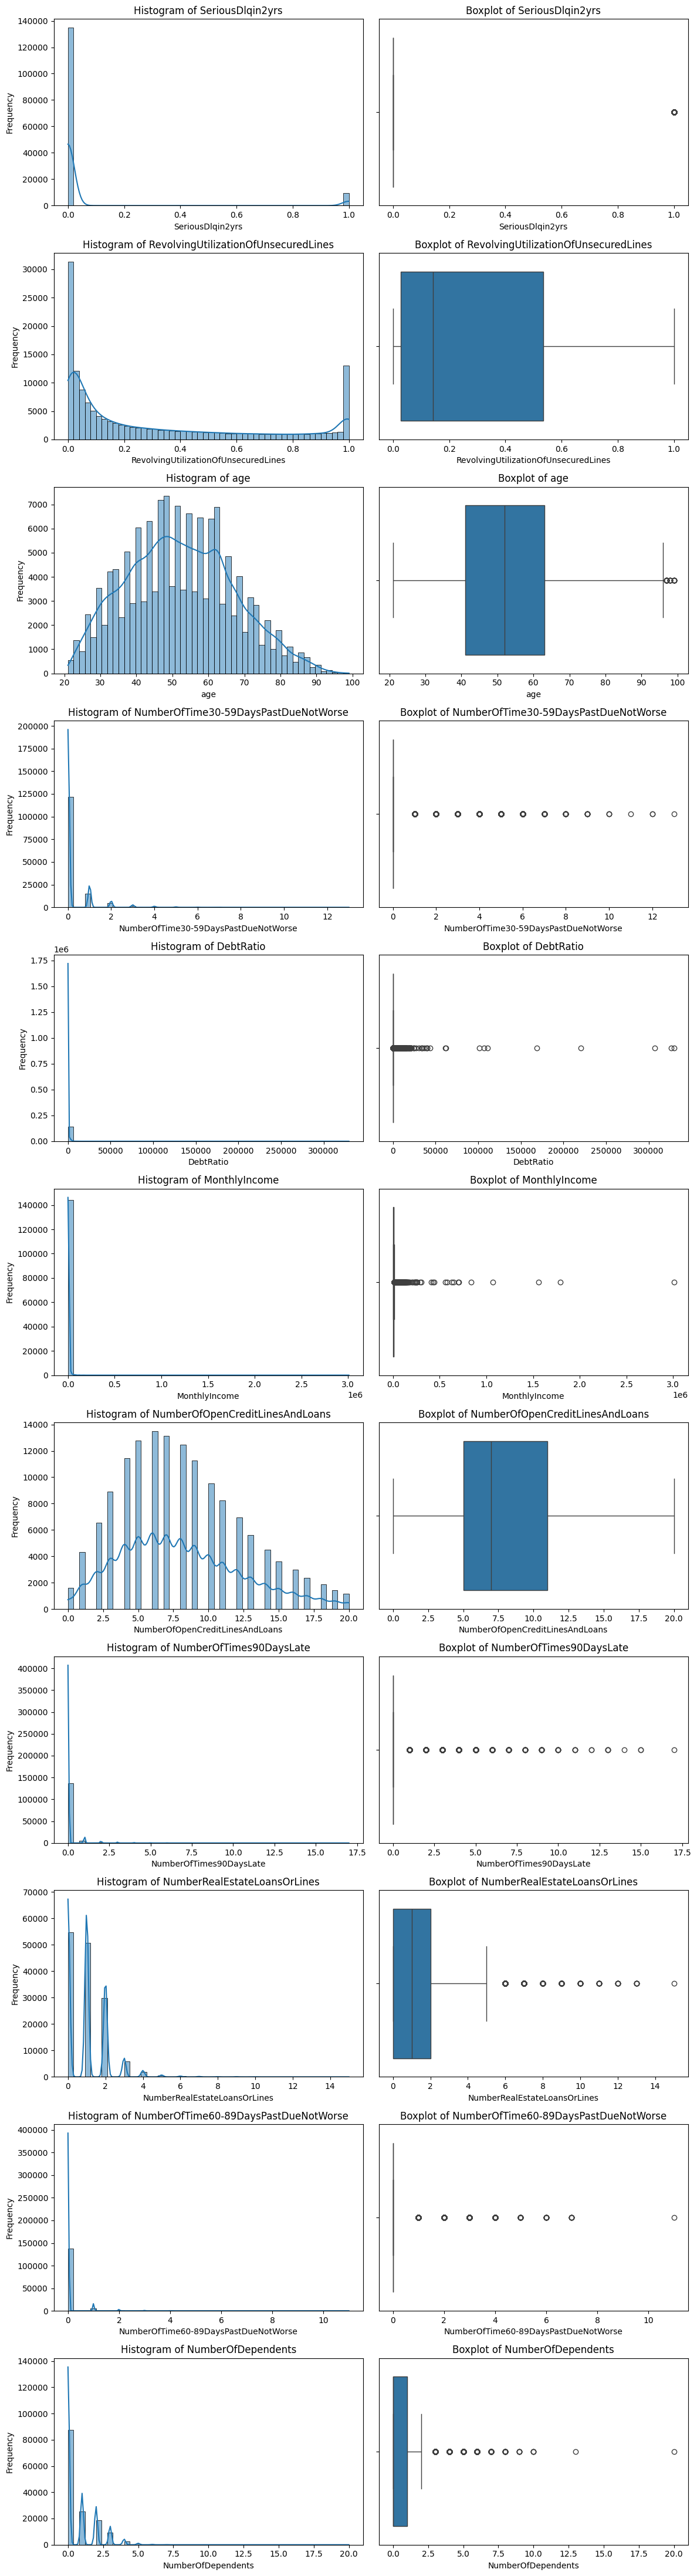

In [6]:
# 수치형 변수 목록 (타겟 제외)

# 기초통계량 출력
# print("기초통계량:")
# print(df.describe())

# 분포 시각화 (히스토그램과 박스플롯)
fig, axes = plt.subplots(len(df.columns), 2, figsize=(12, 4 * len(df.columns)))

for i, col in enumerate(df.columns):
    # 히스토그램 (KDE 포함)
    sns.histplot(df[col], ax=axes[i, 0], kde=True, bins=50)
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    
    # 박스플롯
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

### 2.4 왜도를 기준으로 로그 변환
- 결측치와 논리적 모순이 제거된 데이터 분포를 확인한 결과 왼쪽으로 치우친, 오른쪽으로 꼬리를 가진 분포가 관찰되었다. 따라서 왜도를 확인하여 왜도가 1보다 큰 값을 로그 변환하여 정규분포에 가깝게 변환하였다.

##### 2.4.1 각 변수의 왜도 확인
- 왜도를 확인한 결과, RevolvingUtilizationOfUnsecuredLines, NumberOfOpenCreditLinesAndLoans, age를 제외한 모든 변수가 왜도가 1보다 큰 것으로 나타났다. 

In [7]:
# 수치형 변수들의 왜도 계산
numeric_cols = [col for col in df.columns if col != 'SeriousDlqin2yrs']
skewness = df[numeric_cols].skew().sort_values(ascending=False)

print("=== 변수별 왜도(Skewness) ===")
print(skewness)

print("\n[해석 가이드]")
print("- 왜도 > 1 : 왼쪽으로 치우침 (오른쪽 꼬리가 김)")
print("- 왜도 < -1 : 오른쪽으로 치우침 (왼쪽 꼬리가 김)")
print("- -1 ~ 1 : 비교적 정규분포에 가까움 -> 변환 불필요")

=== 변수별 왜도(Skewness) ===
MonthlyIncome                           131.275111
DebtRatio                               100.759055
NumberOfTimes90DaysLate                   9.141937
NumberOfTime60-89DaysPastDueNotWorse      7.314439
NumberOfTime30-59DaysPastDueNotWorse      4.220374
NumberRealEstateLoansOrLines              1.709337
NumberOfDependents                        1.624404
RevolvingUtilizationOfUnsecuredLines      0.932701
NumberOfOpenCreditLinesAndLoans           0.524842
age                                       0.203903
dtype: float64

[해석 가이드]
- 왜도 > 1 : 왼쪽으로 치우침 (오른쪽 꼬리가 김)
- 왜도 < -1 : 오른쪽으로 치우침 (왼쪽 꼬리가 김)
- -1 ~ 1 : 비교적 정규분포에 가까움 -> 변환 불필요


##### 2.4.2 로그 변환 수행
- 왜도를 확인한 결과를 기준으로 해당 변수들에 대해 로그 변환을 수행하였다.

In [8]:
# 1. 왜도가 1보다 큰 변수만 자동 추출 (age,RevolvingUtilizationOfUnsecuredLines 제외됨)
skewed_cols = skewness[skewness > 1].index.tolist()

print(f"로그 변환 대상 변수 ({len(skewed_cols)}개):")
print(skewed_cols)

# 2. log1p 변환 적용 — 원본(df)은 유지하고, 로그 변수들은 별도 DataFrame df_log에 저장
#    df_log은 같은 인덱스를 사용하며, 로그 변수만 포함합니다.
df_log = pd.DataFrame(index=df.index)
for col in skewed_cols:
    # 음수 값이 있으면 0으로 처리 후 변환 (안전장치)
    df_log[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

print("\n변환 완료! 로그 변환 변수들이 df_log에 생성되었습니다.")
log_cols = [col for col in df_log.columns if col.startswith('log_')]
print(df_log[log_cols].head())


로그 변환 대상 변수 (7개):
['MonthlyIncome', 'DebtRatio', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']

변환 완료! 로그 변환 변수들이 df_log에 생성되었습니다.
   log_MonthlyIncome  log_DebtRatio  log_NumberOfTimes90DaysLate  \
0           9.118335       0.589442                     0.000000   
1           7.863651       0.115002                     0.000000   
2           8.020599       0.081684                     0.693147   
3           8.101981       0.035415                     0.000000   
4          11.060196       0.024620                     0.000000   

   log_NumberOfTime60-89DaysPastDueNotWorse  \
0                                       0.0   
1                                       0.0   
2                                       0.0   
3                                       0.0   
4                                       0.0   

   log_NumberOfTime30-59DaysPastDueNotWorse  log_NumberRealEst

### 2.5 범주형 변수 인코딩
- 범주형 변수는 없다.

In [9]:
# 범주형 변수 자동 인코딩 (더미 변환)
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"범주형 변수 목록: {categorical_cols if categorical_cols else '없음'}")

if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
    print(f"인코딩 완료! 생성된 컬럼 수: {len(df.columns)}")
else:
    print("인코딩할 범주형 변수가 없습니다.")

범주형 변수 목록: 없음
인코딩할 범주형 변수가 없습니다.


### 2.6 스케일링
- 로그 변환하지 않은 변수를 로버스트 스케일링을 수행한다. 또한 다중공선성 완화와 해석의 용이성을 위해 평균 중심화를 수행하였다. 

##### 2.6.1. 로그 변환하지 않은 변수 로버스트 스케일링
- 로그 변환을 수행하지 않은 변수인 age와 RevolvingUtilizationOfUnsecuredLines, NumberOfOpenCreditLinesAndLoans에 대해 로버스트 스케일링을 수행하였다.

In [10]:
robust_scaler = RobustScaler()
# save df_log into df_clean (contains the log-transformed vars)
df_clean = df_log.copy()
# scale original columns from df (2D input required) and store into df_clean
df_clean['age_robust'] = robust_scaler.fit_transform(df[['age']])
df_clean['RevolvingUtilization_robust'] = robust_scaler.fit_transform(df[['RevolvingUtilizationOfUnsecuredLines']])
df_clean['OpenLines_robust'] = robust_scaler.fit_transform(df[['NumberOfOpenCreditLinesAndLoans']])
df_clean['SeriousDlqin2yrs'] = df['SeriousDlqin2yrs'].copy()
print(len(df_clean.columns))
df_clean.head()

11


,log_MonthlyIncome,log_DebtRatio,log_NumberOfTimes90DaysLate,log_NumberOfTime60-89DaysPastDueNotWorse,log_NumberOfTime30-59DaysPastDueNotWorse,log_NumberRealEstateLoansOrLines,log_NumberOfDependents,age_robust,RevolvingUtilization_robust,OpenLines_robust,SeriousDlqin2yrs
0,9.118335,0.589442,0.000000,0.0,1.098612,1.945910,1.098612,-0.318182,1.224592,1.000000,1
1,7.863651,0.115002,0.000000,0.0,0.000000,0.000000,0.693147,-0.545455,1.600258,-0.500000,0
2,8.020599,0.081684,0.693147,0.0,0.693147,0.000000,0.000000,-0.636364,1.012306,-0.833333,0
3,8.101981,0.035415,0.000000,0.0,0.000000,0.000000,0.000000,-1.000000,0.177745,-0.333333,0
4,11.060196,0.024620,0.000000,0.0,0.693147,0.693147,0.000000,-0.136364,1.502102,0.000000,0


##### 2.6.2 로그 변환한 변수 평균 중심화
- 로버스트 스케일링과 로그 변환한 변수들에 대해 평균 중심화를 수행하였다. 그 결과, 변환 후 평균이 0으로 바뀐 것을 확인하였다.

In [11]:
# ====================================================================
# df_clean_all: 로그 변환 변수 + RobustScaler 변수 모두 평균 중심화 적용
# ====================================================================
# 이후 모든 로지스틱 회귀 및 변수 선택에서 df_clean_all 사용

# 1. df_clean에서 _sq, _cb 컬럼 제외하고 복사 (1차항만)
base_cols = [col for col in df_clean.columns if not col.endswith('_sq') and not col.endswith('_cb')]
df_clean_all = df_clean[base_cols].copy()

# 2. 로그 변환된 변수 목록 (중심화 대상)
# 주의: age, RevolvingUtilization, OpenLines는 로버스트 스케일링으로 처리했으므로 제외
log_vars_to_center = [
    'log_MonthlyIncome', 
    'log_DebtRatio', 
    'log_NumberOfTimes90DaysLate',
    'log_NumberOfTime60-89DaysPastDueNotWorse', 
    'log_NumberOfTime30-59DaysPastDueNotWorse',
    'log_NumberRealEstateLoansOrLines', 
    'log_NumberOfDependents'
]

# 3. RobustScaler 적용 변수 목록 (평균 중심화 대상)
robust_vars = ['age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust']

# 4. 타겟 변수
TARGET_COL = 'SeriousDlqin2yrs'

# 5. 로그 변환 변수에 평균 중심화 적용
print("=" * 70)
print("[평균 중심화 적용] 로그 변환 변수")
print("=" * 70)
print(f"{'변수명':<50} {'변환 전 평균':>10} {'변환 후 평균':>10}")
print("-" * 70)

centering_info = {}  # 중심화 정보 저장 (나중에 역변환 시 필요)
for var in log_vars_to_center:
    if var in df_clean_all.columns:
        mean_before = df_clean_all[var].mean()
        centering_info[var] = mean_before
        df_clean_all[var] = df_clean_all[var] - mean_before
        mean_after = df_clean_all[var].mean()
        print(f"{var:<50} {mean_before:>10.4f} {mean_after:>10.6f}")

print("-" * 70)

# 6. RobustScaler 변수에도 평균 중심화 적용
print(f"\n" + "=" * 70)
print("[평균 중심화 적용] RobustScaler 변수")
print("=" * 70)
print(f"{'변수명':<50} {'변환 전 평균':>10} {'변환 후 평균':>10}")
print("-" * 70)

for var in robust_vars:
    if var in df_clean_all.columns:
        mean_before = df_clean_all[var].mean()
        centering_info[var] = mean_before
        df_clean_all[var] = df_clean_all[var] - mean_before
        mean_after = df_clean_all[var].mean()
        print(f"{var:<50} {mean_before:>10.4f} {mean_after:>10.6f}")

print("-" * 70)

# 7. 1차항 변수 목록 정의 (타겟 제외)
feature_pool_all = [col for col in df_clean_all.columns if col != TARGET_COL]

print(f"\n[df_clean_all 최종 구성]")
print(f"  - 전체 컬럼 수: {len(df_clean_all.columns)}개")
print(f"  - 독립 변수 수: {len(feature_pool_all)}개")
print(f"  - 타겟 변수: {TARGET_COL}")
print(f"  - 데이터 크기: {df_clean_all.shape}")
print(f"  - 평균 중심화 적용 변수: {len(centering_info)}개")

print(f"\n[독립 변수 목록]")
print(feature_pool_all)

print(f"\n[평균 중심화 정보 저장됨] centering_info 딕셔너리")
for var, mean_val in centering_info.items():
    print(f"  - {var}: 원래 평균 = {mean_val:.6f}")

# 최종 데이터 확인
df_clean_all.head()

[평균 중심화 적용] 로그 변환 변수
변수명                                                   변환 전 평균    변환 후 평균
----------------------------------------------------------------------
log_MonthlyIncome                                      8.5265  -0.000000
log_DebtRatio                                          1.4798  -0.000000
log_NumberOfTimes90DaysLate                            0.0501  -0.000000
log_NumberOfTime60-89DaysPastDueNotWorse               0.0399   0.000000
log_NumberOfTime30-59DaysPastDueNotWorse               0.1385  -0.000000
log_NumberRealEstateLoansOrLines                       0.5646   0.000000
log_NumberOfDependents                                 0.3953  -0.000000
----------------------------------------------------------------------

[평균 중심화 적용] RobustScaler 변수
변수명                                                   변환 전 평균    변환 후 평균
----------------------------------------------------------------------
age_robust                                             0.0098  -0.000000
Revolvi

,log_MonthlyIncome,log_DebtRatio,log_NumberOfTimes90DaysLate,log_NumberOfTime60-89DaysPastDueNotWorse,log_NumberOfTime30-59DaysPastDueNotWorse,log_NumberRealEstateLoansOrLines,log_NumberOfDependents,age_robust,RevolvingUtilization_robust,OpenLines_robust,SeriousDlqin2yrs
0,0.591813,-0.890373,-0.050109,-0.039949,0.960064,1.381328,0.703282,-0.328024,0.899668,0.827653,1
1,-0.662870,-1.364813,-0.050109,-0.039949,-0.138549,-0.564582,0.297817,-0.555297,1.275333,-0.672347,0
2,-0.505922,-1.398131,0.643039,-0.039949,0.554599,-0.564582,-0.395330,-0.646206,0.687382,-1.005681,0
3,-0.424541,-1.444400,-0.050109,-0.039949,-0.138549,-0.564582,-0.395330,-1.009842,-0.147179,-0.505681,0
4,2.533674,-1.455195,-0.050109,-0.039949,0.554599,0.128565,-0.395330,-0.146206,1.177178,-0.172347,0


# 3. 변수 검토
- 전처리 후 변수들의 VIF와 로지스틱 기본 가정을 확인하였다. 

### 3.1 VIF 확인
- 전처리 후 변수들의 VIF를 확인하였다. 그 결과, 10을 넘는 변수는 없었다.

In [12]:
# VIF 계산 함수 (상수항 추가 버전)
def calculate_vif(df_clean_all, features):
    # VIF 계산을 위해 상수항(Intercept) 추가
    # 상수항이 없으면 원점을 지나는 회귀로 가정되어 VIF가 과대평가될 수 있음 (특히 Age, Income 같은 양수 변수들)
    X = add_constant(df_clean_all[features])
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = features
    
    # X의 0번 컬럼은 'const'이므로, 1번부터 순회하며 VIF 계산
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
    
    return vif_data.sort_values(by='VIF', ascending=False)


print("\n=== 로그 변환 및 스케일링 변수 세트 VIF (상수항 포함; df_clean_all 사용) ===")
# use df_clean_all for VIF of transformed variables so only those columns are evaluated
# 타겟 변수 제외
vif_log = calculate_vif(df_clean_all, [col for col in df_clean_all.columns if col != 'SeriousDlqin2yrs'])
print(vif_log)


=== 로그 변환 및 스케일링 변수 세트 VIF (상수항 포함; df_clean_all 사용) ===


                                    feature       VIF
5          log_NumberRealEstateLoansOrLines  1.360438
9                          OpenLines_robust  1.325510
8               RevolvingUtilization_robust  1.208762
4  log_NumberOfTime30-59DaysPastDueNotWorse  1.203847
3  log_NumberOfTime60-89DaysPastDueNotWorse  1.201019
2               log_NumberOfTimes90DaysLate  1.200460
7                                age_robust  1.157557
6                    log_NumberOfDependents  1.149825
0                         log_MonthlyIncome  1.114565
1                             log_DebtRatio  1.064688


### 3.2 선형성 확인 
- 로지스틱 회귀의 기본 가정 중 하나인 선형성을 확인하기 위해 Box-Tidwell Test를 수행하였다. 그 결과, log_NumberOfDependents_interaction(p-value = 0.926)과 RevolvingUtilization_robust_interaction(p-value = 0.927) 변수가 유의하지 않아 선형성 가정을 만족하는 것으로 나타났다. 그 외의 모든 변수(log_MonthlyIncome, log_DebtRatio, log_NumberOfTimes90DaysLate, log_NumberOfTime60-89DaysPastDueNotWorse, log_NumberOfTime30-59DaysPastDueNotWorse, log_NumberRealEstateLoansOrLines, age_robust, OpenLines_robust)가 유의하여 선형성 가정을 만족하지 않는 것으로 나타났다. 

In [13]:
# Box-Tidwell Test 수행 함수 (개선 버전)
# 로지스틱 회귀의 선형성 가정(독립변수와 로그오즈 간의 선형 관계)을 검정
# 음수 값이 있는 변수도 shift하여 처리 가능하도록 수정
def run_box_tidwell(df_data, features, target_col='SeriousDlqin2yrs'):
    # 타겟 변수를 features에서 제외
    features = [f for f in features if f != target_col]
    
    df_bt = df_data.copy()
    interaction_terms = []
    valid_features = []
    shifted_cols = {}  # shift된 컬럼 정보 저장
    
    for col in features:
        # 음수 값이 있는 경우, 최소값을 shift하여 양수로 변환
        min_val = df_bt[col].min()
        if min_val <= 0:
            shift_amount = abs(min_val) + 0.001  # 약간의 여유 추가
            df_bt[f'{col}_shifted'] = df_bt[col] + shift_amount
            shifted_cols[col] = shift_amount
            work_col = f'{col}_shifted'
        else:
            work_col = col
            
        term_name = f'{col}_interaction'
        # x * ln(x) 계산
        df_bt[term_name] = df_bt[work_col].apply(lambda x: x * np.log(x) if x > 0 else 0)
        
        interaction_terms.append(term_name)
        valid_features.append(col)
    
    # 원본 변수 + 상호작용 항으로 독립변수 구성
    X = df_bt[valid_features + interaction_terms]
    X = sm.add_constant(X)
    y = df_bt[target_col]
    
    try:
        # 로지스틱 회귀 모델 적합
        logit_mod = sm.Logit(y, X)
        result = logit_mod.fit(disp=0) # disp=0: 로그 출력 억제
        return result, interaction_terms, shifted_cols
    except Exception as e:
        return None, str(e), shifted_cols

# ============================================================
# Box-Tidwell 검정: 1차항 변수만 대상 (평균 중심화 적용된 변수)
# ============================================================
# 1차항 변수만 선택 (_sq 제외)
first_order_vars = [col for col in df_clean_all.columns 
                    if col != 'SeriousDlqin2yrs' and not col.endswith('_sq')]

print("=== Box-Tidwell Test (1차항 변수만, 평균 중심화 적용됨) ===")
print(f"검정 대상 변수: {first_order_vars}\n")

# 1차항 변수만 포함된 데이터프레임 생성
df_first_order = df_clean_all[first_order_vars + ['SeriousDlqin2yrs']].copy()

res_log, inter_log, shifted = run_box_tidwell(df_first_order, first_order_vars)

if shifted:
    print(f"[참고] 음수 값으로 인해 shift된 변수: {list(shifted.keys())}\n")

if res_log:
    print(res_log.summary().tables[1])
    print(f"\n[해석]")
    print(f"-> _interaction 항의 P-value < 0.05: 비선형성 의심 (2차항 추가 권장)")
    print(f"-> _interaction 항의 P-value >= 0.05: 선형성 만족 (2차항 불필요)")
else:
    print("Error:", inter_log)

=== Box-Tidwell Test (1차항 변수만, 평균 중심화 적용됨) ===
검정 대상 변수: ['log_MonthlyIncome', 'log_DebtRatio', 'log_NumberOfTimes90DaysLate', 'log_NumberOfTime60-89DaysPastDueNotWorse', 'log_NumberOfTime30-59DaysPastDueNotWorse', 'log_NumberRealEstateLoansOrLines', 'log_NumberOfDependents', 'age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust']

[참고] 음수 값으로 인해 shift된 변수: ['log_MonthlyIncome', 'log_DebtRatio', 'log_NumberOfTimes90DaysLate', 'log_NumberOfTime60-89DaysPastDueNotWorse', 'log_NumberOfTime30-59DaysPastDueNotWorse', 'log_NumberRealEstateLoansOrLines', 'log_NumberOfDependents', 'age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust']

[참고] 음수 값으로 인해 shift된 변수: ['log_MonthlyIncome', 'log_DebtRatio', 'log_NumberOfTimes90DaysLate', 'log_NumberOfTime60-89DaysPastDueNotWorse', 'log_NumberOfTime30-59DaysPastDueNotWorse', 'log_NumberRealEstateLoansOrLines', 'log_NumberOfDependents', 'age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust']

                                 

### 3.3 독립성 확인 
- 로지스틱 회귀의 기본 가정 중 하나인 독립성을 확인하기 위하여 runs test를 수행하였다. 그 결과, statistic=-0.4778, p-value=0.6328 으로 p-value가 0.05보다 커서 귀무가설을 기각하지 못하였으며, 이는 잔차들이 독립적임을 의미한다.

In [14]:
from statsmodels.sandbox.stats.runs import runstest_1samp

# 모델 적합 및 Pearson 잔차 계산
target_col = 'SeriousDlqin2yrs'
features = [col for col in df_clean_all.columns if col != target_col]

X = sm.add_constant(df_clean_all[features])
y = df_clean_all[target_col]
model = sm.Logit(y, X).fit(disp=0)

# Pearson 잔차 계산
pearson_resid = model.resid_pearson

# Pearson 잔차에 대해 런 검정
stat, p_value = runstest_1samp(pearson_resid, cutoff='mean')
print(f"Runs Test: statistic={stat:.4f}, p-value={p_value:.4f}")
# p > 0.05 → 독립성 가정 만족

Runs Test: statistic=-0.4778, p-value=0.6328


# 4. 변수 선택 
전진선택, 후진제거법, 단계선택법 중 결과가 가장 좋은 방법을 선택하여 변수를 선택하였다.

### 4.1 이차 회귀식 적용
- 3.2 선형성 확인 결과, 대부분의 변수가 선형성 가정을 만족하지 않는 것을 확인하였다. 따라서 선형성을 가정을 만족하는 변수와 만족하지 않는 변수를 일차항에, 선형성을 만족하지 않는 변수를 이차항에도 포함시키는 이차 회귀식을 적용하였다.
    - 선형성 위반: log_MonthlyIncome(p < 0.001), log_DebtRatio(p < 0.001), log_NumberOfTimes90DaysLate(p < 0.001), log_NumberOfTime60-89DaysPastDueNotWorse(p < 0.001), log_NumberOfTime30-59DaysPastDueNotWorse(p < 0.001), log_NumberRealEstateLoansOrLines(p < 0.001), age_robust(p < 0.001), OpenLines_robust(p < 0.001)
    - 선형성 만족: log_NumberOfDependents(p = 0.926), RevolvingUtilization_robust(p = 0.927)

In [15]:
# 변수 선택 공통 설정 (2차 다항 회귀식 적용)
# Box-Tidwell 검정 결과, 대부분의 변수에서 비선형성이 발견되어 2차항 추가
warnings.filterwarnings("ignore", category=RuntimeWarning)

TARGET_COL = "SeriousDlqin2yrs"

# df_clean_all 기반 feature pool 구성 (평균 중심화 적용된 데이터 사용)
# df_clean_all에는 이미 로그 변환 + robust 스케일링 + 평균 중심화가 적용됨
feature_pool_linear = [col for col in df_clean_all.columns if col != TARGET_COL]

print("=== 원본 1차항 변수 목록 ===")
print(f"변수 수: {len(feature_pool_linear)}개")
for i, var in enumerate(feature_pool_linear, 1):
    print(f"  {i}. {var}")

# 2차항 생성 (Box-Tidwell에서 비선형성이 확인된 변수들에 대해)
# Box-Tidwell 검정 결과 (p < 0.05인 변수만 2차항 추가):
# - log_NumberOfDependents: p=0.926 → 선형성 만족 (2차항 불필요)
# - RevolvingUtilization_robust: p=0.927 → 선형성 만족 (2차항 불필요)
nonlinear_vars = [
    'log_MonthlyIncome',                          # p < 0.001
    'log_DebtRatio',                              # p < 0.001
    'log_NumberOfTimes90DaysLate',                # p < 0.001
    'log_NumberOfTime60-89DaysPastDueNotWorse',   # p < 0.001
    'log_NumberOfTime30-59DaysPastDueNotWorse',   # p < 0.001
    'log_NumberRealEstateLoansOrLines',           # p < 0.001
    'age_robust',                                  # p < 0.001
    'OpenLines_robust'                             # p < 0.001
]

# 선형성 만족 변수 (2차항 불필요)
linear_vars = [
    'log_NumberOfDependents',       # p = 0.926
    'RevolvingUtilization_robust'   # p = 0.927
]

print("\n=== Box-Tidwell 검정 기반 비선형성 판단 ===")
print(f"\n[비선형성 확인] 2차항 추가 대상 (p < 0.05):")
for var in nonlinear_vars:
    print(f"  - {var}")
print(f"\n[선형성 만족] 2차항 불필요 (p >= 0.05):")
for var in linear_vars:
    print(f"  - {var}")

# 2차항 컬럼 생성 (df_clean_all에 추가)
for var in nonlinear_vars:
    if var in df_clean_all.columns:
        df_clean_all[f'{var}_sq'] = df_clean_all[var] ** 2

# feature pool에 2차항 추가
feature_pool = feature_pool_linear.copy()
for var in nonlinear_vars:
    sq_col = f'{var}_sq'
    if sq_col in df_clean_all.columns:
        feature_pool.append(sq_col)

print(f"\n=== 2차 다항 회귀식 적용 결과 ===")
print(f"원본 변수 수: {len(feature_pool_linear)}")
print(f"추가된 2차항 수: {len(feature_pool) - len(feature_pool_linear)}")
print(f"총 변수 수: {len(feature_pool)}")
print(f"\n2차항 변수: {[v for v in feature_pool if v.endswith('_sq')]}")

X_full = df_clean_all[feature_pool].copy()
y = df_clean_all[TARGET_COL].copy()
selection_records = {}  # 각 방법별 결과를 저장할 딕셔너리

=== 원본 1차항 변수 목록 ===
변수 수: 10개
  1. log_MonthlyIncome
  2. log_DebtRatio
  3. log_NumberOfTimes90DaysLate
  4. log_NumberOfTime60-89DaysPastDueNotWorse
  5. log_NumberOfTime30-59DaysPastDueNotWorse
  6. log_NumberRealEstateLoansOrLines
  7. log_NumberOfDependents
  8. age_robust
  9. RevolvingUtilization_robust
  10. OpenLines_robust

=== Box-Tidwell 검정 기반 비선형성 판단 ===

[비선형성 확인] 2차항 추가 대상 (p < 0.05):
  - log_MonthlyIncome
  - log_DebtRatio
  - log_NumberOfTimes90DaysLate
  - log_NumberOfTime60-89DaysPastDueNotWorse
  - log_NumberOfTime30-59DaysPastDueNotWorse
  - log_NumberRealEstateLoansOrLines
  - age_robust
  - OpenLines_robust

[선형성 만족] 2차항 불필요 (p >= 0.05):
  - log_NumberOfDependents
  - RevolvingUtilization_robust

=== 2차 다항 회귀식 적용 결과 ===
원본 변수 수: 10
추가된 2차항 수: 8
총 변수 수: 18

2차항 변수: ['log_MonthlyIncome_sq', 'log_DebtRatio_sq', 'log_NumberOfTimes90DaysLate_sq', 'log_NumberOfTime60-89DaysPastDueNotWorse_sq', 'log_NumberOfTime30-59DaysPastDueNotWorse_sq', 'log_NumberRealEstateLoansOr

### 4.2 선택된 변수
- mlxtend 패키지를 사용하여 전진선택법, 후진제거법, 단계선택법을 적용하여 변수 선택을 진행했다. neg_log_loss를 기준으로 선택한 결과, 각 방법이 동일하게 17개 변수를 선택하였다. 
    - 1차항(9개): log_MonthlyIncome, log_DebtRatio, log_NumberOfTimes90DaysLate, log_NumberOfTime60-89DaysPastDueNotWorse, log_NumberOfTime30-59DaysPastDueNotWorse, log_NumberOfDependents, age_robust, RevolvingUtilization_robust, OpenLines_robust

    - 2차항(8개): log_MonthlyIncome_sq, log_DebtRatio_sq, log_NumberOfTimes90DaysLate_sq, log_NumberOfTime60-89DaysPastDueNotWorse_sq, log_NumberOfTime30-59DaysPastDueNotWorse_sq, log_NumberRealEstateLoansOrLines_sq, age_robust_sq, OpenLines_robust_sq
    - 제외된 변수: log_NumberRealEstateLoansOrLines (1차항)

In [16]:

# 이전 셀에서 정의된 X_full, y 사용
print(f"사용할 변수 수: {X_full.shape[1]}개")
print(f"샘플 수: {X_full.shape[0]}개")

# 전진선택 (Forward)
sfs_forward = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000), 
    k_features='best',
    forward=True,      # 전진선택
    scoring='neg_log_loss',
    cv=5,
    n_jobs=-1
)
sfs_forward.fit(X_full, y)

print(f"\n=== 전진선택 결과 ===")
print(f"선택된 변수 수: {len(sfs_forward.k_feature_idx_)}")
print(f"선택된 변수: {list(sfs_forward.k_feature_names_)}")

# 후진제거 (Backward)
sfs_backward = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000), 
    k_features='best',
    forward=False,     # 후진제거
    scoring='neg_log_loss',
    cv=5,
    n_jobs=-1
)
sfs_backward.fit(X_full, y)

print(f"\n=== 후진제거 결과 ===")
print(f"선택된 변수 수: {len(sfs_backward.k_feature_idx_)}")
print(f"선택된 변수: {list(sfs_backward.k_feature_names_)}")

# 단계선택법 (Stepwise - Floating Forward)
sfs_stepwise = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000), 
    k_features='best',
    forward=True,      
    floating=True,     # 단계선택 (floating 활성화)
    scoring='neg_log_loss',
    cv=5,
    n_jobs=-1
)
sfs_stepwise.fit(X_full, y)

print(f"\n=== 단계선택법 (SFFS) 결과 ===")
print(f"선택된 변수 수: {len(sfs_stepwise.k_feature_idx_)}")
print(f"선택된 변수: {list(sfs_stepwise.k_feature_names_)}")

사용할 변수 수: 18개
샘플 수: 144228개

=== 전진선택 결과 ===
선택된 변수 수: 17
선택된 변수: ['log_MonthlyIncome', 'log_DebtRatio', 'log_NumberOfTimes90DaysLate', 'log_NumberOfTime60-89DaysPastDueNotWorse', 'log_NumberOfTime30-59DaysPastDueNotWorse', 'log_NumberOfDependents', 'age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust', 'log_MonthlyIncome_sq', 'log_DebtRatio_sq', 'log_NumberOfTimes90DaysLate_sq', 'log_NumberOfTime60-89DaysPastDueNotWorse_sq', 'log_NumberOfTime30-59DaysPastDueNotWorse_sq', 'log_NumberRealEstateLoansOrLines_sq', 'age_robust_sq', 'OpenLines_robust_sq']

=== 전진선택 결과 ===
선택된 변수 수: 17
선택된 변수: ['log_MonthlyIncome', 'log_DebtRatio', 'log_NumberOfTimes90DaysLate', 'log_NumberOfTime60-89DaysPastDueNotWorse', 'log_NumberOfTime30-59DaysPastDueNotWorse', 'log_NumberOfDependents', 'age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust', 'log_MonthlyIncome_sq', 'log_DebtRatio_sq', 'log_NumberOfTimes90DaysLate_sq', 'log_NumberOfTime60-89DaysPastDueNotWorse_sq', 'log_NumberOfTime30-59

# 5. 최종 모델 summary
- 변수 선택에서 선택된 변수 조합을 사용하여 최종 로지스틱 회귀 모델을 적합하였다.

##### 5.1 로지스틱 모델 적합
- 선택된 변수를 사용하여 로지스틱 회귀 모델을 적합하였다. 그 결과, 17개의 변수로 최종 모델이 적합되었다. VIF 확인 결과, 10을 넘는 변수는 없어 다중공선성이 심각하지 않았으며 모든 변수의 p-value가 0.05보다 작아 유의한 것으로 나타났다. 

In [17]:
# 세 가지 변수선택 방법(전진/후진/단계)이 동일하게 선택한 변수로 최종 모델 적합


# 선택된 변수 (전진/후진/단계 선택법이 동일하게 선택한 조합 - 17개)
selected_features = [
    'log_MonthlyIncome', 
    'log_DebtRatio', 
    'log_NumberOfTimes90DaysLate', 
    'log_NumberOfTime60-89DaysPastDueNotWorse', 
    'log_NumberOfTime30-59DaysPastDueNotWorse', 
    'log_NumberOfDependents', 
    'age_robust', 
    'RevolvingUtilization_robust', 
    'OpenLines_robust', 
    'log_MonthlyIncome_sq',
    'log_DebtRatio_sq', 
    'log_NumberOfTimes90DaysLate_sq', 
    'log_NumberOfTime60-89DaysPastDueNotWorse_sq', 
    'log_NumberOfTime30-59DaysPastDueNotWorse_sq', 
    'log_NumberRealEstateLoansOrLines_sq',
    'age_robust_sq',
    'OpenLines_robust_sq'
]

print(f"=== 최종 선택된 변수 ({len(selected_features)}개) ===")
print("(전진선택, 후진제거, 단계선택법 모두 동일한 조합 선택)")
print(selected_features)

# 최종 모델 적합
X_selected = X_full[selected_features]
X_selected_const = sm.add_constant(X_selected)
final_model = sm.Logit(y, X_selected_const).fit(disp=0)

# VIF 계산
print("\n=== VIF (다중공선성 진단) ===")
vif_data = pd.DataFrame()
vif_data["Variable"] = selected_features
vif_data["VIF"] = [variance_inflation_factor(X_selected.values, i) for i in range(len(selected_features))]
vif_data["VIF"] = vif_data["VIF"].round(2)
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

# VIF 해석 기준 추가
def vif_status(vif):
    if vif < 5:
        return "✅ 양호"
    elif vif < 10:
        return "⚠️ 주의"
    else:
        return "❌ 심각"

vif_data["Status"] = vif_data["VIF"].apply(vif_status)
display(vif_data)

print(f"\n※ VIF 해석: < 5 양호, 5~10 주의, > 10 다중공선성 심각")

# 메트릭 출력
print("\n=== 최종 모델 메트릭 ===")
metrics = pd.Series({
    "n_features": len(selected_features),
    "AIC": final_model.aic,
    "BIC": final_model.bic,
    "Pseudo R²": final_model.prsquared,
    "Log-Likelihood": final_model.llf,
}, name="Final Model Metrics")
display(metrics)

print("\n" + "="*60)
print("Final Model Summary:")
print("="*60)
print(final_model.summary())

=== 최종 선택된 변수 (17개) ===
(전진선택, 후진제거, 단계선택법 모두 동일한 조합 선택)
['log_MonthlyIncome', 'log_DebtRatio', 'log_NumberOfTimes90DaysLate', 'log_NumberOfTime60-89DaysPastDueNotWorse', 'log_NumberOfTime30-59DaysPastDueNotWorse', 'log_NumberOfDependents', 'age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust', 'log_MonthlyIncome_sq', 'log_DebtRatio_sq', 'log_NumberOfTimes90DaysLate_sq', 'log_NumberOfTime60-89DaysPastDueNotWorse_sq', 'log_NumberOfTime30-59DaysPastDueNotWorse_sq', 'log_NumberRealEstateLoansOrLines_sq', 'age_robust_sq', 'OpenLines_robust_sq']

=== VIF (다중공선성 진단) ===

=== VIF (다중공선성 진단) ===


,Variable,VIF,Status
0,log_DebtRatio_sq,8.47,⚠️ 주의
1,log_NumberOfTime60-89DaysPastDueNotWorse_sq,7.42,⚠️ 주의
2,log_NumberOfTime60-89DaysPastDueNotWorse,7.37,⚠️ 주의
3,log_DebtRatio,7.36,⚠️ 주의
4,log_NumberOfTimes90DaysLate,6.49,⚠️ 주의
5,log_NumberOfTimes90DaysLate_sq,6.34,⚠️ 주의
6,log_NumberOfTime30-59DaysPastDueNotWorse_sq,5.20,⚠️ 주의
7,log_NumberOfTime30-59DaysPastDueNotWorse,4.83,✅ 양호
8,log_MonthlyIncome,2.13,✅ 양호
9,log_MonthlyIncome_sq,1.97,✅ 양호



※ VIF 해석: < 5 양호, 5~10 주의, > 10 다중공선성 심각

=== 최종 모델 메트릭 ===


n_features           17.000000
AIC               52585.769303
BIC               52763.594015
Pseudo R²             0.252116
Log-Likelihood   -26274.884651
Name: Final Model Metrics, dtype: float64


Final Model Summary:
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               144228
Model:                          Logit   Df Residuals:                   144210
Method:                           MLE   Df Model:                           17
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.2521
Time:                        14:05:53   Log-Likelihood:                -26275.
converged:                       True   LL-Null:                       -35132.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
const                                          -3.2128      0.034    -94.637      0.000      -3.279      -3.146
log_Monthl

### 5.2 부트스트랩
- 최종 모델의 안정성을 평가하기 위해 부트스트랩을 수행하였다. 1000번의 부트스트랩 샘플링을 통해 각 변수의 계수 추정치와 신뢰구간을 계산하였다. 그 결과, 모든 변수의 신뢰구간이 0을 포함하지 않아 모델의 안정성이 확인되었다.

In [18]:
# 부트스트랩 반복 횟수
n_boot = 1000

# 재현성을 위한 랜덤 시드 설정
np.random.seed(42)

# 부트스트랩 계수 저장 리스트
boot_coefs = []

# 원본 데이터 (이전 셀에서 정의된 selected_features, X_selected, final_model 사용)
X_boot = X_selected
y_boot = y

print(f"부트스트래핑 시작: {n_boot}회 반복")
print(f"사용 변수: {len(selected_features)}개")

for i in range(n_boot):
    # 부트스트랩 샘플 생성 (복원 추출)
    indices = np.random.choice(len(X_boot), size=len(X_boot), replace=True)
    X_sample = X_boot.iloc[indices]
    y_sample = y_boot.iloc[indices]
    
    # 모델 적합
    X_sample_const = sm.add_constant(X_sample)
    try:
        model_boot = sm.Logit(y_sample, X_sample_const).fit(disp=0, maxiter=200)
        boot_coefs.append(model_boot.params.values)
    except:
        # 적합 실패 시 스킵
        continue

# 부트스트랩 계수 배열로 변환
boot_coefs = np.array(boot_coefs)

print(f"성공한 부트스트랩 샘플 수: {len(boot_coefs)}")

# 계수별 통계 계산
coef_names = ['const'] + selected_features
for i, name in enumerate(coef_names):
    coef_boot = boot_coefs[:, i]
    mean_coef = np.mean(coef_boot)
    std_coef = np.std(coef_boot)
    ci_lower = np.percentile(coef_boot, 2.5)
    ci_upper = np.percentile(coef_boot, 97.5)
    
    print(f"\n{name}:")
    print(f"  평균 계수: {mean_coef:.4f}")
    print(f"  표준편차: {std_coef:.4f}")
    print(f"  95% 신뢰구간: ({ci_lower:.4f}, {ci_upper:.4f})")

# 원본 모델 계수와 비교
original_coefs = final_model.params
print("\n\n=== 원본 모델 계수 ===")
for name, coef in zip(coef_names, original_coefs):
    print(f"  {name}: {coef:.4f}")

부트스트래핑 시작: 1000회 반복
사용 변수: 17개
성공한 부트스트랩 샘플 수: 998

const:
  평균 계수: -3.2131
  표준편차: 0.0332
  95% 신뢰구간: (-3.2773, -3.1466)

log_MonthlyIncome:
  평균 계수: -0.2376
  표준편차: 0.0234
  95% 신뢰구간: (-0.2821, -0.1936)

log_DebtRatio:
  평균 계수: 0.1294
  표준편차: 0.0177
  95% 신뢰구간: (0.0960, 0.1634)

log_NumberOfTimes90DaysLate:
  평균 계수: 2.2457
  표준편차: 0.0859
  95% 신뢰구간: (2.0795, 2.4196)

log_NumberOfTime60-89DaysPastDueNotWorse:
  평균 계수: 1.6792
  표준편차: 0.1119
  95% 신뢰구간: (1.4626, 1.8947)

log_NumberOfTime30-59DaysPastDueNotWorse:
  평균 계수: 1.2698
  표준편차: 0.0579
  95% 신뢰구간: (1.1556, 1.3874)

log_NumberOfDependents:
  평균 계수: 0.1120
  표준편차: 0.0248
  95% 신뢰구간: (0.0620, 0.1582)

age_robust:
  평균 계수: -0.4057
  표준편차: 0.0224
  95% 신뢰구간: (-0.4501, -0.3635)

RevolvingUtilization_robust:
  평균 계수: 0.8039
  표준편차: 0.0188
  95% 신뢰구간: (0.7682, 0.8420)

OpenLines_robust:
  평균 계수: 0.0873
  표준편차: 0.0216
  95% 신뢰구간: (0.0443, 0.1302)

log_MonthlyIncome_sq:
  평균 계수: -0.0455
  표준편차: 0.0059
  95% 신뢰구간: (-0.0578, -0.0350)

log_De

## 부록

단계적 기법

In [ ]:
# # Stepwise Selection (전진/후진 혼합, 함수 없이 실행)
# print("=== Stepwise Selection ===")
# stepwise_remaining = feature_pool.copy()
# stepwise_selected = []
# stepwise_history_rows = []
# stepwise_best_model = None
# stepwise_best_metrics = None

# changed = True
# while stepwise_remaining and changed:
#     changed = False
#     candidate_records = []
#     for feat in stepwise_remaining:
#         trial_features = stepwise_selected + [feat]
#         X_trial = sm.add_constant(X_full[trial_features], has_constant="add")
#         try:
#             trial_model = sm.Logit(y, X_trial).fit(disp=0, maxiter=200)
#             trial_metrics = {
#                 "features": trial_features.copy(),
#                 "n_features": len(trial_features),
#                 "aic": float(trial_model.aic),
#                 "bic": float(trial_model.bic),
#                 "pseudo_r2": float(1 - (trial_model.llf / trial_model.llnull)),
#             }
#             candidate_records.append({"feature": feat, "model": trial_model, "metrics": trial_metrics})
#         except Exception as exc:
#             print(f"⚠️ stepwise skip adding {feat}: {exc}")
#     if candidate_records:
#         best_candidate = min(candidate_records, key=lambda item: item["metrics"]["bic"])
#         if (stepwise_best_metrics is None) or (best_candidate["metrics"]["bic"] < stepwise_best_metrics["bic"] - 1e-6):
#             stepwise_selected.append(best_candidate["feature"])
#             stepwise_remaining.remove(best_candidate["feature"])
#             stepwise_best_model = best_candidate["model"]
#             stepwise_best_metrics = best_candidate["metrics"]
#             stepwise_history_rows.append(
#                 {
#                     "step": len(stepwise_history_rows) + 1,
#                     "action": f"+ {best_candidate['feature']}",
#                     "bic": best_candidate["metrics"]["bic"],
#                     "features": stepwise_selected.copy(),
#                 }
#             )
#             changed = True
#     removed = True
#     while removed and len(stepwise_selected) > 1:
#         removed = False
#         candidate_records = []
#         for feat in stepwise_selected:
#             trial_features = [f for f in stepwise_selected if f != feat]
#             X_trial = sm.add_constant(X_full[trial_features], has_constant="add")
#             try:
#                 trial_model = sm.Logit(y, X_trial).fit(disp=0, maxiter=200)
#                 trial_metrics = {
#                     "features": trial_features.copy(),
#                     "n_features": len(trial_features),
#                     "aic": float(trial_model.aic),
#                     "bic": float(trial_model.bic),
#                     "pseudo_r2": float(1 - (trial_model.llf / trial_model.llnull)),
#                 }
#                 candidate_records.append({"feature": feat, "model": trial_model, "metrics": trial_metrics})
#             except Exception as exc:
#                 print(f"⚠️ stepwise skip removing {feat}: {exc}")
#         if not candidate_records:
#             break
#         best_candidate = min(candidate_records, key=lambda item: item["metrics"]["bic"])
#         if stepwise_best_metrics and (best_candidate["metrics"]["bic"] < stepwise_best_metrics["bic"] - 1e-6):
#             stepwise_selected.remove(best_candidate["feature"])
#             if best_candidate["feature"] not in stepwise_remaining:
#                 stepwise_remaining.append(best_candidate["feature"])
#             stepwise_best_model = best_candidate["model"]
#             stepwise_best_metrics = best_candidate["metrics"]
#             stepwise_history_rows.append(
#                 {
#                     "step": len(stepwise_history_rows) + 1,
#                     "action": f"- {best_candidate['feature']}",
#                     "bic": best_candidate["metrics"]["bic"],
#                     "features": stepwise_selected.copy(),
#                 }
#             )
#             removed = True
#             changed = True

# stepwise_history = pd.DataFrame(stepwise_history_rows) if stepwise_history_rows else None
# selection_records["Stepwise"] = {"best": {"model": stepwise_best_model, "metrics": stepwise_best_metrics}, "history": stepwise_history}
# if stepwise_best_metrics:
#     display(pd.Series(stepwise_best_metrics, name="Stepwise Best Metrics"))
# if stepwise_history is not None:
#     print("Stepwise Selection History:")
#     display(stepwise_history)

후진제거

In [ ]:
# # Backward Elimination (함수 없이 반복문으로 실행)
# print("=== Backward Elimination ===")
# backward_selected = feature_pool.copy()
# backward_history_rows = []
# backward_best_model = None
# backward_best_metrics = None

# if backward_selected:
#     X_start = sm.add_constant(X_full[backward_selected], has_constant="add")
#     try:
#         start_model = sm.Logit(y, X_start).fit(disp=0, maxiter=200)
#         backward_best_model = start_model
#         backward_best_metrics = {
#             "features": backward_selected.copy(),
#             "n_features": len(backward_selected),
#             "aic": float(start_model.aic),
#             "bic": float(start_model.bic),
#             "pseudo_r2": float(1 - (start_model.llf / start_model.llnull)),
#         }
#         backward_history_rows.append(
#             {
#                 "step": len(backward_selected),
#                 "action": "start",
#                 "bic": backward_best_metrics["bic"],
#                 "features": backward_selected.copy(),
#             }
#         )
#     except Exception as exc:
#         print(f"⚠️ backward start failed: {exc}")

# improved = True
# while improved and len(backward_selected) > 1:
#     improved = False
#     candidate_records = []
#     for feat in backward_selected:
#         trial_features = [f for f in backward_selected if f != feat]
#         X_trial = sm.add_constant(X_full[trial_features], has_constant="add")
#         try:
#             trial_model = sm.Logit(y, X_trial).fit(disp=0, maxiter=200)
#             trial_metrics = {
#                 "features": trial_features.copy(),
#                 "n_features": len(trial_features),
#                 "aic": float(trial_model.aic),
#                 "bic": float(trial_model.bic),
#                 "pseudo_r2": float(1 - (trial_model.llf / trial_model.llnull)),
#             }
#             candidate_records.append({"removed": feat, "model": trial_model, "metrics": trial_metrics})
#         except Exception as exc:
#             print(f"⚠️ backward skip removing {feat}: {exc}")
#     if not candidate_records:
#         break
#     best_candidate = min(candidate_records, key=lambda item: item["metrics"]["bic"])
#     if backward_best_metrics and (best_candidate["metrics"]["bic"] < backward_best_metrics["bic"] - 1e-6):
#         backward_selected.remove(best_candidate["removed"])
#         backward_best_model = best_candidate["model"]
#         backward_best_metrics = best_candidate["metrics"]
#         backward_history_rows.append(
#             {
#                 "step": len(backward_selected),
#                 "action": f"- {best_candidate['removed']}",
#                 "bic": best_candidate["metrics"]["bic"],
#                 "features": backward_selected.copy(),
#             }
#         )
#         improved = True

# backward_history = pd.DataFrame(backward_history_rows) if backward_history_rows else None
# selection_records["Backward"] = {"best": {"model": backward_best_model, "metrics": backward_best_metrics}, "history": backward_history}
# if backward_best_metrics:
#     display(pd.Series(backward_best_metrics, name="Backward Best Metrics"))
# if backward_history is not None:
#     print("Backward Elimination History:")
#     display(backward_history)

전진선택

In [ ]:
# # Forward Selection (함수 없이 반복문으로 실행)
# print("=== Forward Selection ===")
# forward_remaining = feature_pool.copy()
# forward_selected = []
# forward_history_rows = []
# forward_best_model = None
# forward_best_metrics = None

# while forward_remaining:
#     candidate_records = []
#     for feat in forward_remaining:
#         trial_features = forward_selected + [feat]
#         X_trial = sm.add_constant(X_full[trial_features], has_constant="add")
#         try:
#             trial_model = sm.Logit(y, X_trial).fit(disp=0, maxiter=200)
#             trial_metrics = {
#                 "features": trial_features.copy(),
#                 "n_features": len(trial_features),
#                 "aic": float(trial_model.aic),
#                 "bic": float(trial_model.bic),
#                 "pseudo_r2": float(1 - (trial_model.llf / trial_model.llnull)),
#             }
#             candidate_records.append({"feature": feat, "model": trial_model, "metrics": trial_metrics})
#         except Exception as exc:
#             print(f"⚠️ forward skip {trial_features}: {exc}")
#     if not candidate_records:
#         break
#     best_candidate = min(candidate_records, key=lambda item: item["metrics"]["bic"])
#     if (forward_best_metrics is None) or (best_candidate["metrics"]["bic"] < forward_best_metrics["bic"] - 1e-6):
#         forward_selected.append(best_candidate["feature"])
#         forward_remaining.remove(best_candidate["feature"])
#         forward_best_model = best_candidate["model"]
#         forward_best_metrics = best_candidate["metrics"]
#         forward_history_rows.append(
#             {
#                 "step": len(forward_history_rows) + 1,
#                 "action": f"+ {best_candidate['feature']}",
#                 "bic": best_candidate["metrics"]["bic"],
#                 "features": forward_selected.copy(),
#             }
#         )
#     else:
#         break

# forward_history = pd.DataFrame(forward_history_rows) if forward_history_rows else None
# selection_records["Forward"] = {"best": {"model": forward_best_model, "metrics": forward_best_metrics}, "history": forward_history}
# if forward_best_metrics:
#     display(pd.Series(forward_best_metrics, name="Forward Best Metrics"))
# if forward_history is not None:
#     print("Forward Selection History:")
#     display(forward_history)

In [ ]:
# import statsmodels.api as sm
# import pandas as pd
# import warnings
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# # ====================================================================
# # 전체 변수를 사용한 1차, 2차, 3차 모델 비교 (df_clean_all 사용)
# # ====================================================================

# # 폰트 설정을 리스트 형태로 전달하여, 앞의 폰트에 없으면 뒤의 폰트를 사용하게 함
# plt.rcParams['font.family'] = ['Malgun Gothic', 'Segoe UI Emoji']

# # 마이너스 기호 깨짐 방지 (한글 폰트 설정 시 필수)
# plt.rcParams['axes.unicode_minus'] = False

# # 경고 메시지 무시
# warnings.filterwarnings("ignore", category=RuntimeWarning)

# # --- 1. 변수 목록 정의 ---
# TARGET_COL = "SeriousDlqin2yrs"

# # 1-1. 1차항 변수 목록 정의 (df_clean_all에서 타겟 및 파생변수 제외)
# feature_pool_linear = [col for col in df_clean_all.columns 
#                        if col != TARGET_COL and not col.endswith('_sq') and not col.endswith('_cb')]

# print("=" * 70)
# print("[1차항 변수 목록] (df_clean_all 기반)")
# print("=" * 70)
# print(feature_pool_linear)
# print(f"총 {len(feature_pool_linear)}개 변수\n")

# # 1-2. 비선형 변환을 적용할 변수 목록 (Box-Tidwell 검정 결과 기반)
# # p < 0.05인 변수만 비선형 처리 (log_MonthlyIncome, log_NumberOfDependents 제외)
# nonlinear_vars = [
#     'log_DebtRatio', 
#     'log_NumberOfTimes90DaysLate',
#     'log_NumberOfTime60-89DaysPastDueNotWorse', 
#     'log_NumberOfTime30-59DaysPastDueNotWorse',
#     'log_NumberRealEstateLoansOrLines', 
#     'log_NumberOfOpenCreditLinesAndLoans',
#     'age_robust', 
#     'RevolvingUtilization_robust'
# ]

# # 1-3. VIF 문제 변수 제외한 비선형 변수 목록 (Model B-lite용)
# nonlinear_vars_lite = [
#     'log_DebtRatio', 
#     'log_NumberOfTimes90DaysLate',
#     'log_NumberOfTime60-89DaysPastDueNotWorse', 
#     'log_NumberOfTime30-59DaysPastDueNotWorse',
#     'log_NumberRealEstateLoansOrLines', 
#     'log_NumberOfOpenCreditLinesAndLoans',
#     'age_robust'
#     # 'RevolvingUtilization_robust' 제외 (VIF > 10)
# ]

# print("[비선형 변수 목록] (Box-Tidwell p < 0.05)")
# print(nonlinear_vars)
# print(f"총 {len(nonlinear_vars)}개 변수\n")

# print("[Model B-lite용 비선형 변수] (VIF > 10 변수 제외)")
# print(nonlinear_vars_lite)
# print(f"총 {len(nonlinear_vars_lite)}개 변수 (RevolvingUtilization_robust 제외)\n")
# # --- 2. 데이터 준비 (df_clean_all 기반) ---
# # 기존 _sq, _cb 컬럼 제거 후 복사
# base_cols = [col for col in df_clean_all.columns if not col.endswith('_sq') and not col.endswith('_cb')]
# df_linear = df_clean_all[base_cols].copy()     # 1차항용
# df_poly2 = df_clean_all[base_cols].copy()      # 2차항용 (Model B)
# df_poly2_lite = df_clean_all[base_cols].copy() # 2차항용 (Model B-lite)
# df_poly3 = df_clean_all[base_cols].copy()      # 3차항용
# df_poly3 = df_clean_all.copy()      # 3차항용

# # 2-1. 2차항 컬럼 생성 (비선형 변수만) - Model B
# for var in nonlinear_vars:
#     if var in df_poly2.columns:
#         df_poly2[f'{var}_sq'] = df_poly2[var] ** 2

# # 2-2. 2차항 컬럼 생성 (VIF 문제 변수 제외) - Model B-lite
# for var in nonlinear_vars_lite:
#     if var in df_poly2_lite.columns:
#         df_poly2_lite[f'{var}_sq'] = df_poly2_lite[var] ** 2

# # 2-3. 3차항 컬럼 생성 (1차 + 2차 + 3차, 비선형 변수만)
# for var in nonlinear_vars:
#     if var in df_poly3.columns:
#         df_poly3[f'{var}_sq'] = df_poly3[var] ** 2
#         df_poly3[f'{var}_cb'] = df_poly3[var] ** 3

# # 2-4. 변수 목록 생성
# feature_pool_poly2 = feature_pool_linear.copy()
# for var in nonlinear_vars:
#     sq_col = f'{var}_sq'
#     if sq_col in df_poly2.columns:
#         feature_pool_poly2.append(sq_col)

# feature_pool_poly2_lite = feature_pool_linear.copy()
# for var in nonlinear_vars_lite:
#     sq_col = f'{var}_sq'
#     if sq_col in df_poly2_lite.columns:
#         feature_pool_poly2_lite.append(sq_col)

# feature_pool_poly3 = feature_pool_linear.copy()
# for var in nonlinear_vars:
#     sq_col = f'{var}_sq'
#     cb_col = f'{var}_cb'
#     if sq_col in df_poly3.columns:
#         feature_pool_poly3.append(sq_col)
#     if cb_col in df_poly3.columns:
#         feature_pool_poly3.append(cb_col)

# print("[2차항 추가 변수 - Model B]")
# print([v for v in feature_pool_poly2 if v.endswith('_sq')])
# print(f"총 {len(feature_pool_poly2)}개 변수\n")

# print("[2차항 추가 변수 - Model B-lite] (RevolvingUtilization_robust_sq 제외)")
# print([v for v in feature_pool_poly2_lite if v.endswith('_sq')])
# print(f"총 {len(feature_pool_poly2_lite)}개 변수\n")

# print("[3차항 추가 변수]")
# print([v for v in feature_pool_poly3 if v.endswith('_cb')])
# print(f"총 {len(feature_pool_poly3)}개 변수\n")

# # --- 3. 모델 학습 및 BIC 계산 ---
# y = df_linear[TARGET_COL]

# # 모델 A: 1차항 모델
# print("=" * 70)
# print("[모델 A] 1차항 모델 피팅")
# print("=" * 70)
# X_linear = sm.add_constant(df_linear[feature_pool_linear])
# model_linear = sm.Logit(y, X_linear)
# results_linear = model_linear.fit(disp=0, maxiter=100)
# bic_linear = results_linear.bic
# aic_linear = results_linear.aic
# pseudo_r2_linear = 1 - (results_linear.llf / results_linear.llnull)
# print(f"BIC: {bic_linear:.4f}")
# print(f"AIC: {aic_linear:.4f}")
# print(f"Pseudo R²: {pseudo_r2_linear:.4f}\n")

# # 모델 B: 2차항 모델 (전체)
# print("=" * 70)
# print("[모델 B] 2차항 모델 피팅 (8개 비선형 변수)")
# print("=" * 70)
# y_poly2 = df_poly2[TARGET_COL]
# X_poly2 = sm.add_constant(df_poly2[feature_pool_poly2])
# model_poly2 = sm.Logit(y_poly2, X_poly2)
# results_poly2 = model_poly2.fit(disp=0, maxiter=100)
# bic_poly2 = results_poly2.bic
# aic_poly2 = results_poly2.aic
# pseudo_r2_poly2 = 1 - (results_poly2.llf / results_poly2.llnull)
# print(f"BIC: {bic_poly2:.4f}")
# print(f"AIC: {aic_poly2:.4f}")
# print(f"Pseudo R²: {pseudo_r2_poly2:.4f}\n")

# # 모델 B-lite: 수정된 2차항 모델 (VIF 문제 변수 제외)
# print("=" * 70)
# print("[모델 B-lite] 수정된 2차항 모델 (RevolvingUtilization_robust_sq 제외)")
# print("=" * 70)
# y_poly2_lite = df_poly2_lite[TARGET_COL]
# X_poly2_lite = sm.add_constant(df_poly2_lite[feature_pool_poly2_lite])
# model_poly2_lite = sm.Logit(y_poly2_lite, X_poly2_lite)
# results_poly2_lite = model_poly2_lite.fit(disp=0, maxiter=100)
# bic_poly2_lite = results_poly2_lite.bic
# aic_poly2_lite = results_poly2_lite.aic
# pseudo_r2_poly2_lite = 1 - (results_poly2_lite.llf / results_poly2_lite.llnull)
# print(f"BIC: {bic_poly2_lite:.4f}")
# print(f"AIC: {aic_poly2_lite:.4f}")
# print(f"Pseudo R²: {pseudo_r2_poly2_lite:.4f}\n")

# # 모델 C: 3차항 모델
# print("=" * 70)
# print("[모델 C] 3차항 모델 피팅")
# print("=" * 70)
# y_poly3 = df_poly3[TARGET_COL]
# X_poly3 = sm.add_constant(df_poly3[feature_pool_poly3])
# model_poly3 = sm.Logit(y_poly3, X_poly3)
# results_poly3 = model_poly3.fit(disp=0, maxiter=200)
# bic_poly3 = results_poly3.bic
# aic_poly3 = results_poly3.aic
# pseudo_r2_poly3 = 1 - (results_poly3.llf / results_poly3.llnull)
# print(f"BIC: {bic_poly3:.4f}")
# print(f"AIC: {aic_poly3:.4f}")
# print(f"Pseudo R²: {pseudo_r2_poly3:.4f}\n")


# # --- 4. 모델 비교 및 결론 ---
# print("=" * 90)
# print("[결론] 모델 비교 (df_clean_all 기반)")
# print("=" * 90)
# print(f"{'지표':<12} {'모델A(1차)':<14} {'모델B(2차)':<14} {'모델B-lite':<14} {'모델C(3차)':<14}")
# print("-" * 90)
# print(f"{'변수 수':<12} {len(feature_pool_linear):<14} {len(feature_pool_poly2):<14} {len(feature_pool_poly2_lite):<14} {len(feature_pool_poly3):<14}")
# print(f"{'BIC':<12} {bic_linear:<14.2f} {bic_poly2:<14.2f} {bic_poly2_lite:<14.2f} {bic_poly3:<14.2f}")
# print(f"{'AIC':<12} {aic_linear:<14.2f} {aic_poly2:<14.2f} {aic_poly2_lite:<14.2f} {aic_poly3:<14.2f}")
# print(f"{'Pseudo R²':<12} {pseudo_r2_linear:<14.4f} {pseudo_r2_poly2:<14.4f} {pseudo_r2_poly2_lite:<14.4f} {pseudo_r2_poly3:<14.4f}")
# print("-" * 90)

# # 최적 모델 결정
# bic_values = {'1차항(A)': bic_linear, '2차항(B)': bic_poly2, '2차항-lite(B-lite)': bic_poly2_lite, '3차항(C)': bic_poly3}
# best_model = min(bic_values, key=bic_values.get)

# print(f"\n>> BIC 기준 최적 모델: {best_model} (BIC = {bic_values[best_model]:.2f})")


# # --- 5. Model B vs Model B-lite 비교 분석 ---
# print("\n")
# print("=" * 90)
# print("[핵심 분석] Model B vs Model B-lite 비교")
# print("=" * 90)
# bic_diff_b_blite = bic_poly2_lite - bic_poly2
# aic_diff_b_blite = aic_poly2_lite - aic_poly2
# pseudo_r2_diff = pseudo_r2_poly2 - pseudo_r2_poly2_lite

# print(f"\n{'지표':<20} {'Model B':<15} {'Model B-lite':<15} {'차이':<15}")
# print("-" * 65)
# print(f"{'변수 수':<20} {len(feature_pool_poly2):<15} {len(feature_pool_poly2_lite):<15} {len(feature_pool_poly2) - len(feature_pool_poly2_lite):<15}")
# print(f"{'BIC':<20} {bic_poly2:<15.2f} {bic_poly2_lite:<15.2f} {bic_diff_b_blite:+15.2f}")
# print(f"{'AIC':<20} {aic_poly2:<15.2f} {aic_poly2_lite:<15.2f} {aic_diff_b_blite:+15.2f}")
# print(f"{'Pseudo R²':<20} {pseudo_r2_poly2:<15.4f} {pseudo_r2_poly2_lite:<15.4f} {-pseudo_r2_diff:+15.4f}")
# print("-" * 65)

# print(f"\n[BIC 차이 해석]")
# print(f"   BIC(B-lite) - BIC(B) = {bic_diff_b_blite:+.2f}")

# if bic_diff_b_blite < 2:
#     print(f"\n   ✅ 결론: BIC 차이가 2 미만 → Model B-lite 채택 권장")
#     print(f"      - RevolvingUtilization_robust_sq 제거해도 모델 성능 저하 미미")
#     print(f"      - VIF 안정성 확보로 계수 해석 신뢰도 향상")
#     recommended_model = "B-lite"
# elif bic_diff_b_blite < 6:
#     print(f"\n   ⚠️ 결론: BIC 차이가 2~6 → 약간의 성능 저하 있음")
#     print(f"      - VIF 안정성 vs 예측력 trade-off 고려 필요")
#     print(f"      - 해석 가능성이 중요하면 Model B-lite 선택")
#     recommended_model = "B-lite (해석 중시)"
# elif bic_diff_b_blite < 10:
#     print(f"\n   ⚠️ 결론: BIC 차이가 6~10 → 상당한 성능 저하")
#     print(f"      - RevolvingUtilization_robust_sq가 중요한 정보 포함")
#     print(f"      - 예측력 중시하면 Model B 유지")
#     recommended_model = "B (예측력 중시)"
# else:
#     print(f"\n   ❌ 결론: BIC 차이가 10 이상 → 심각한 성능 저하")
#     print(f"      - RevolvingUtilization_robust_sq가 매우 중요한 변수")
#     print(f"      - Model B 유지 권장 (VIF 높아도 예측력 우선)")
#     recommended_model = "B"

# print(f"\n>> 권장 모델: Model {recommended_model}")


# # --- 6. VIF(분산팽창요인) 요약표 ---
# print("\n")
# print("=" * 90)
# print("[VIF 분석] 다중공선성 진단 (중심화 적용 후)")
# print("=" * 90)

# def calc_vif(X_df):
#     """VIF 계산 함수"""
#     vif_data = []
#     cols = [c for c in X_df.columns if c != 'const']
#     X_no_const = X_df[cols]
    
#     for i, col in enumerate(cols):
#         vif_val = variance_inflation_factor(X_no_const.values, i)
#         vif_data.append({'변수': col, 'VIF': vif_val})
    
#     return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# # 각 모델별 VIF 계산
# print("\n--- [1차항 모델] VIF ---")
# vif_linear = calc_vif(X_linear)
# vif_linear['다중공선성'] = vif_linear['VIF'].apply(lambda x: '⚠ 심각 (>10)' if x > 10 else ('주의 (5~10)' if x > 5 else '양호 (<5)'))
# print(vif_linear.to_string(index=False))
# print(f"\n>> VIF > 10 변수 수: {(vif_linear['VIF'] > 10).sum()}개")

# print("\n--- [2차항 모델 B] VIF ---")
# vif_poly2 = calc_vif(X_poly2)
# vif_poly2['다중공선성'] = vif_poly2['VIF'].apply(lambda x: '⚠ 심각 (>10)' if x > 10 else ('주의 (5~10)' if x > 5 else '양호 (<5)'))
# print(vif_poly2.to_string(index=False))
# print(f"\n>> VIF > 10 변수 수: {(vif_poly2['VIF'] > 10).sum()}개")

# print("\n--- [2차항 모델 B-lite] VIF ---")
# vif_poly2_lite = calc_vif(X_poly2_lite)
# vif_poly2_lite['다중공선성'] = vif_poly2_lite['VIF'].apply(lambda x: '⚠ 심각 (>10)' if x > 10 else ('주의 (5~10)' if x > 5 else '양호 (<5)'))
# print(vif_poly2_lite.to_string(index=False))
# print(f"\n>> VIF > 10 변수 수: {(vif_poly2_lite['VIF'] > 10).sum()}개")

# print("\n--- [3차항 모델] VIF ---")
# vif_poly3 = calc_vif(X_poly3)
# vif_poly3['다중공선성'] = vif_poly3['VIF'].apply(lambda x: '⚠ 심각 (>10)' if x > 10 else ('주의 (5~10)' if x > 5 else '양호 (<5)'))
# print(vif_poly3.to_string(index=False))
# print(f"\n>> VIF > 10 변수 수: {(vif_poly3['VIF'] > 10).sum()}개")

# # VIF 비교 요약표
# print("\n" + "=" * 90)
# print("[VIF 요약 비교]")
# print("=" * 90)
# vif_summary = pd.DataFrame({
#     '모델': ['1차항(A)', '2차항(B)', '2차항(B-lite)', '3차항(C)'],
#     '변수 수': [len(feature_pool_linear), len(feature_pool_poly2), len(feature_pool_poly2_lite), len(feature_pool_poly3)],
#     'VIF>10': [(vif_linear['VIF'] > 10).sum(), (vif_poly2['VIF'] > 10).sum(), (vif_poly2_lite['VIF'] > 10).sum(), (vif_poly3['VIF'] > 10).sum()],
#     'VIF>5': [(vif_linear['VIF'] > 5).sum(), (vif_poly2['VIF'] > 5).sum(), (vif_poly2_lite['VIF'] > 5).sum(), (vif_poly3['VIF'] > 5).sum()],
#     'VIF최대': [vif_linear['VIF'].max(), vif_poly2['VIF'].max(), vif_poly2_lite['VIF'].max(), vif_poly3['VIF'].max()],
#     'VIF평균': [vif_linear['VIF'].mean(), vif_poly2['VIF'].mean(), vif_poly2_lite['VIF'].mean(), vif_poly3['VIF'].mean()]
# })
# print(vif_summary.to_string(index=False))

# print("\n[최종 권장사항]")
# print("- 해석 가능성 중시: Model B-lite (VIF 안정, 계수 신뢰도 높음)")
# print("- 예측력 중시: Model B 또는 Model C (VIF 높아도 예측력 우선)")

In [ ]:
# # Durbin-Watson Test 수행 함수
# # 잔차의 자기상관을 검정하여 독립성 가정 확인
# def check_independence(df_clean_all, features, target_col='SeriousDlqin2yrs'):
#     # 타겟 변수를 features에서 제외
#     features = [f for f in features if f != target_col]
    
#     # 모델 적합 (Interaction 항 없는 순수 모델)
#     X = sm.add_constant(df_clean_all[features])
#     y = df_clean[target_col]
    
#     try:
#         model = sm.Logit(y, X).fit(disp=0)
#         # 모델의 잔차 계산 (resid_response 사용)
#         residuals = model.resid_response
#         # Durbin-Watson 통계 계산
#         dw_stat = durbin_watson(residuals)
#         return dw_stat
#     except Exception as e:
#         return None

# # 2. 로그 변환 변수 세트
# print("\n=== 로그 변환 변수 세트 Durbin-Watson ===")
# dw_log = check_independence(df_clean_all, df_clean_all.columns)
# if dw_log:
#     print(f"Durbin-Watson statistic: {dw_log:.4f}")
# else:
#     print("Error calculating Durbin-Watson")

# # 해석 가이드
# print("\n[Durbin-Watson Test 해석]")
# print("값이 2에 가까울수록 잔차 간 자기상관이 없음 (독립성 만족).")
# print("- 0 ~ 2: 양의 자기상관 (잔차가 연속적으로 비슷한 패턴).")
# print("- 2: 자기상관 없음.")
# print("- 2 ~ 4: 음의 자기상관 (잔차가 교대로 변동).")
# print("주의: 로지스틱 회귀에서는 잔차가 이진형이므로 이 테스트의 유용성이 제한적일 수 있음.")

In [19]:
# ====================================================================
# 1차 회귀식 vs 2차 회귀식 AIC/BIC 비교
# ====================================================================

# ====================================================================
# [비교 A] 변수 선택 없이 전체 변수로 비교
# ====================================================================
print("=" * 80)
print("[비교 A] 변수 선택 없이 전체 변수로 1차 vs 2차 회귀식 비교")
print("=" * 80)

# 전체 1차항 변수 (10개)
all_linear_features = [
    'log_MonthlyIncome', 
    'log_DebtRatio', 
    'log_NumberOfTimes90DaysLate', 
    'log_NumberOfTime60-89DaysPastDueNotWorse', 
    'log_NumberOfTime30-59DaysPastDueNotWorse', 
    'log_NumberRealEstateLoansOrLines',
    'log_NumberOfDependents', 
    'age_robust', 
    'RevolvingUtilization_robust', 
    'OpenLines_robust'
]

# 전체 2차 회귀식 변수 (1차항 10개 + 2차항 8개 = 18개)
all_quadratic_features = all_linear_features + [
    'log_MonthlyIncome_sq',
    'log_DebtRatio_sq', 
    'log_NumberOfTimes90DaysLate_sq', 
    'log_NumberOfTime60-89DaysPastDueNotWorse_sq', 
    'log_NumberOfTime30-59DaysPastDueNotWorse_sq', 
    'log_NumberRealEstateLoansOrLines_sq',
    'age_robust_sq',
    'OpenLines_robust_sq'
]

# 모델 적합 (전체 변수)
X_all_linear = sm.add_constant(df_clean_all[all_linear_features])
model_all_linear = sm.Logit(y, X_all_linear).fit(disp=0)

X_all_quadratic = sm.add_constant(df_clean_all[all_quadratic_features])
model_all_quadratic = sm.Logit(y, X_all_quadratic).fit(disp=0)

print(f"\n[전체 1차 회귀식] 변수 {len(all_linear_features)}개")
print(f"[전체 2차 회귀식] 변수 {len(all_quadratic_features)}개 (1차항 {len(all_linear_features)}개 + 2차항 {len(all_quadratic_features) - len(all_linear_features)}개)")

# 비교 테이블 생성 (비교 A)
comparison_A = pd.DataFrame({
    '지표': ['변수 수', 'AIC', 'BIC', 'Pseudo R²', 'Log-Likelihood'],
    '1차 회귀식 (전체)': [
        len(all_linear_features),
        f"{model_all_linear.aic:,.2f}",
        f"{model_all_linear.bic:,.2f}",
        f"{model_all_linear.prsquared:.4f}",
        f"{model_all_linear.llf:,.2f}"
    ],
    '2차 회귀식 (전체)': [
        len(all_quadratic_features),
        f"{model_all_quadratic.aic:,.2f}",
        f"{model_all_quadratic.bic:,.2f}",
        f"{model_all_quadratic.prsquared:.4f}",
        f"{model_all_quadratic.llf:,.2f}"
    ]
})

display(comparison_A)

# 차이 계산 (비교 A)
aic_diff_A = model_all_linear.aic - model_all_quadratic.aic
bic_diff_A = model_all_linear.bic - model_all_quadratic.bic
pseudo_r2_diff_A = model_all_quadratic.prsquared - model_all_linear.prsquared

print(f"\n📊 AIC 차이 (1차 - 2차): {aic_diff_A:+,.2f}")
print(f"📊 BIC 차이 (1차 - 2차): {bic_diff_A:+,.2f}")
print(f"📊 Pseudo R² 향상: {pseudo_r2_diff_A:+.4f} ({pseudo_r2_diff_A*100:+.2f}%p)")

if aic_diff_A > 0:
    print(f"\n✅ AIC: 2차 회귀식이 {aic_diff_A:,.2f} 낮음 → 2차 회귀식 선호")
else:
    print(f"\n❌ AIC: 1차 회귀식이 {-aic_diff_A:,.2f} 낮음 → 1차 회귀식 선호")

if bic_diff_A > 0:
    print(f"✅ BIC: 2차 회귀식이 {bic_diff_A:,.2f} 낮음 → 2차 회귀식 선호")
else:
    print(f"❌ BIC: 1차 회귀식이 {-bic_diff_A:,.2f} 낮음 → 1차 회귀식 선호")


# ====================================================================
# [비교 B] 변수 선택 적용 후 비교
# ====================================================================
print("\n\n" + "=" * 80)
print("[비교 B] 변수 선택 적용 후 1차 vs 2차 회귀식 비교")
print("=" * 80)

# 1차 회귀식에 대한 변수 선택 수행
print("\n[1차 회귀식 변수 선택 진행 중...]")
X_linear_full = df_clean_all[all_linear_features]

sfs_linear = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000), 
    k_features='best',
    forward=True,      
    floating=True,     # 단계선택법 (SFFS)
    scoring='neg_log_loss',
    cv=5,
    n_jobs=-1
)
sfs_linear.fit(X_linear_full, y)

# 선택된 1차 회귀식 변수
selected_linear_features = list(sfs_linear.k_feature_names_)
print(f"\n[1차 회귀식 변수 선택 결과]")
print(f"  선택된 변수 수: {len(selected_linear_features)}개")
print(f"  선택된 변수: {selected_linear_features}")

# 기존 2차 회귀식 선택 결과 사용 (이미 선택된 17개 변수)
selected_quadratic_features = [
    'log_MonthlyIncome', 
    'log_DebtRatio', 
    'log_NumberOfTimes90DaysLate', 
    'log_NumberOfTime60-89DaysPastDueNotWorse', 
    'log_NumberOfTime30-59DaysPastDueNotWorse', 
    'log_NumberOfDependents', 
    'age_robust', 
    'RevolvingUtilization_robust', 
    'OpenLines_robust', 
    'log_MonthlyIncome_sq',
    'log_DebtRatio_sq', 
    'log_NumberOfTimes90DaysLate_sq', 
    'log_NumberOfTime60-89DaysPastDueNotWorse_sq', 
    'log_NumberOfTime30-59DaysPastDueNotWorse_sq', 
    'log_NumberRealEstateLoansOrLines_sq',
    'age_robust_sq',
    'OpenLines_robust_sq'
]

print(f"\n[2차 회귀식 변수 선택 결과] (기존 결과 사용)")
print(f"  선택된 변수 수: {len(selected_quadratic_features)}개")
print(f"  1차항: {[v for v in selected_quadratic_features if not v.endswith('_sq')]}")
print(f"  2차항: {[v for v in selected_quadratic_features if v.endswith('_sq')]}")

# 모델 적합 (선택된 변수)
X_selected_linear = sm.add_constant(df_clean_all[selected_linear_features])
model_selected_linear = sm.Logit(y, X_selected_linear).fit(disp=0)

X_selected_quadratic = sm.add_constant(df_clean_all[selected_quadratic_features])
model_selected_quadratic = sm.Logit(y, X_selected_quadratic).fit(disp=0)

# 비교 테이블 생성 (비교 B)
comparison_B = pd.DataFrame({
    '지표': ['변수 수', 'AIC', 'BIC', 'Pseudo R²', 'Log-Likelihood'],
    '1차 회귀식 (선택)': [
        len(selected_linear_features),
        f"{model_selected_linear.aic:,.2f}",
        f"{model_selected_linear.bic:,.2f}",
        f"{model_selected_linear.prsquared:.4f}",
        f"{model_selected_linear.llf:,.2f}"
    ],
    '2차 회귀식 (선택)': [
        len(selected_quadratic_features),
        f"{model_selected_quadratic.aic:,.2f}",
        f"{model_selected_quadratic.bic:,.2f}",
        f"{model_selected_quadratic.prsquared:.4f}",
        f"{model_selected_quadratic.llf:,.2f}"
    ]
})

display(comparison_B)

# 차이 계산 (비교 B)
aic_diff_B = model_selected_linear.aic - model_selected_quadratic.aic
bic_diff_B = model_selected_linear.bic - model_selected_quadratic.bic
pseudo_r2_diff_B = model_selected_quadratic.prsquared - model_selected_linear.prsquared

print(f"\n📊 AIC 차이 (1차 - 2차): {aic_diff_B:+,.2f}")
print(f"📊 BIC 차이 (1차 - 2차): {bic_diff_B:+,.2f}")
print(f"📊 Pseudo R² 향상: {pseudo_r2_diff_B:+.4f} ({pseudo_r2_diff_B*100:+.2f}%p)")

if aic_diff_B > 0:
    print(f"\n✅ AIC: 2차 회귀식이 {aic_diff_B:,.2f} 낮음 → 2차 회귀식 선호")
else:
    print(f"\n❌ AIC: 1차 회귀식이 {-aic_diff_B:,.2f} 낮음 → 1차 회귀식 선호")

if bic_diff_B > 0:
    print(f"✅ BIC: 2차 회귀식이 {bic_diff_B:,.2f} 낮음 → 2차 회귀식 선호")
else:
    print(f"❌ BIC: 1차 회귀식이 {-bic_diff_B:,.2f} 낮음 → 1차 회귀식 선호")


# ====================================================================
# [종합 비교] 4개 모델 비교
# ====================================================================
print("\n\n" + "=" * 80)
print("[종합 비교] 4개 모델 AIC/BIC 비교")
print("=" * 80)

summary_df = pd.DataFrame({
    '모델': [
        '1차 (전체, 10개)',
        '2차 (전체, 18개)',
        f'1차 (선택, {len(selected_linear_features)}개)',
        f'2차 (선택, 17개)'
    ],
    '변수 수': [
        len(all_linear_features),
        len(all_quadratic_features),
        len(selected_linear_features),
        len(selected_quadratic_features)
    ],
    'AIC': [
        model_all_linear.aic,
        model_all_quadratic.aic,
        model_selected_linear.aic,
        model_selected_quadratic.aic
    ],
    'BIC': [
        model_all_linear.bic,
        model_all_quadratic.bic,
        model_selected_linear.bic,
        model_selected_quadratic.bic
    ],
    'Pseudo R²': [
        model_all_linear.prsquared,
        model_all_quadratic.prsquared,
        model_selected_linear.prsquared,
        model_selected_quadratic.prsquared
    ]
})

# 숫자 포맷팅
summary_df['AIC'] = summary_df['AIC'].apply(lambda x: f"{x:,.2f}")
summary_df['BIC'] = summary_df['BIC'].apply(lambda x: f"{x:,.2f}")
summary_df['Pseudo R²'] = summary_df['Pseudo R²'].apply(lambda x: f"{x:.4f}")

display(summary_df)

# 최적 모델 결정
all_models = {
    '1차 (전체)': model_all_linear,
    '2차 (전체)': model_all_quadratic,
    '1차 (선택)': model_selected_linear,
    '2차 (선택)': model_selected_quadratic
}

best_aic_model = min(all_models, key=lambda k: all_models[k].aic)
best_bic_model = min(all_models, key=lambda k: all_models[k].bic)

print(f"\n[최적 모델]")
print(f"  📊 AIC 기준 최적: {best_aic_model} (AIC = {all_models[best_aic_model].aic:,.2f})")
print(f"  📊 BIC 기준 최적: {best_bic_model} (BIC = {all_models[best_bic_model].bic:,.2f})")

# BIC 차이 해석 (최종)
print("\n" + "=" * 80)
print("[결론]")
print("=" * 80)

# 변수 선택 효과 분석
print("\n[1] 변수 선택 효과:")
print(f"   - 1차 회귀식: AIC {model_all_linear.aic - model_selected_linear.aic:+,.2f} 개선")
print(f"   - 2차 회귀식: AIC {model_all_quadratic.aic - model_selected_quadratic.aic:+,.2f} 개선")

# 2차항 추가 효과 분석
print("\n[2] 2차항 추가 효과:")
print(f"   - 전체 변수: AIC {model_all_linear.aic - model_all_quadratic.aic:+,.2f} (2차가 낮으면 양수)")
print(f"   - 선택 변수: AIC {model_selected_linear.aic - model_selected_quadratic.aic:+,.2f} (2차가 낮으면 양수)")

if best_aic_model == best_bic_model:
    print(f"\n✅ AIC와 BIC 모두 '{best_aic_model}' 모델을 최적으로 선택")
else:
    print(f"\n⚠️ AIC({best_aic_model})와 BIC({best_bic_model})가 다른 모델 선택")
    print("   → BIC는 변수 수 페널티가 더 크므로 간명한 모델 선호")

[비교 A] 변수 선택 없이 전체 변수로 1차 vs 2차 회귀식 비교

[전체 1차 회귀식] 변수 10개
[전체 2차 회귀식] 변수 18개 (1차항 10개 + 2차항 8개)

[전체 1차 회귀식] 변수 10개
[전체 2차 회귀식] 변수 18개 (1차항 10개 + 2차항 8개)


,지표,1차 회귀식 (전체),2차 회귀식 (전체)
0,변수 수,10,18
1,AIC,"53,255.92","52,587.05"
2,BIC,"53,364.59","52,774.75"
3,Pseudo R²,0.2424,0.2521
4,Log-Likelihood,"-26,616.96","-26,274.52"



📊 AIC 차이 (1차 - 2차): +668.87
📊 BIC 차이 (1차 - 2차): +589.84
📊 Pseudo R² 향상: +0.0097 (+0.97%p)

✅ AIC: 2차 회귀식이 668.87 낮음 → 2차 회귀식 선호
✅ BIC: 2차 회귀식이 589.84 낮음 → 2차 회귀식 선호


[비교 B] 변수 선택 적용 후 1차 vs 2차 회귀식 비교

[1차 회귀식 변수 선택 진행 중...]

[1차 회귀식 변수 선택 결과]
  선택된 변수 수: 8개
  선택된 변수: ['log_MonthlyIncome', 'log_NumberOfTimes90DaysLate', 'log_NumberOfTime60-89DaysPastDueNotWorse', 'log_NumberOfTime30-59DaysPastDueNotWorse', 'log_NumberOfDependents', 'age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust']

[2차 회귀식 변수 선택 결과] (기존 결과 사용)
  선택된 변수 수: 17개
  1차항: ['log_MonthlyIncome', 'log_DebtRatio', 'log_NumberOfTimes90DaysLate', 'log_NumberOfTime60-89DaysPastDueNotWorse', 'log_NumberOfTime30-59DaysPastDueNotWorse', 'log_NumberOfDependents', 'age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust']
  2차항: ['log_MonthlyIncome_sq', 'log_DebtRatio_sq', 'log_NumberOfTimes90DaysLate_sq', 'log_NumberOfTime60-89DaysPastDueNotWorse_sq', 'log_NumberOfTime30-59DaysPastDueNotWorse_sq', 'log_NumberRealE

,지표,1차 회귀식 (선택),2차 회귀식 (선택)
0,변수 수,8,17
1,AIC,"53,255.58","52,585.77"
2,BIC,"53,344.49","52,763.59"
3,Pseudo R²,0.2423,0.2521
4,Log-Likelihood,"-26,618.79","-26,274.88"



📊 AIC 차이 (1차 - 2차): +669.81
📊 BIC 차이 (1차 - 2차): +580.90
📊 Pseudo R² 향상: +0.0098 (+0.98%p)

✅ AIC: 2차 회귀식이 669.81 낮음 → 2차 회귀식 선호
✅ BIC: 2차 회귀식이 580.90 낮음 → 2차 회귀식 선호


[종합 비교] 4개 모델 AIC/BIC 비교


,모델,변수 수,AIC,BIC,Pseudo R²
0,"1차 (전체, 10개)",10,"53,255.92","53,364.59",0.2424
1,"2차 (전체, 18개)",18,"52,587.05","52,774.75",0.2521
2,"1차 (선택, 8개)",8,"53,255.58","53,344.49",0.2423
3,"2차 (선택, 17개)",17,"52,585.77","52,763.59",0.2521



[최적 모델]
  📊 AIC 기준 최적: 2차 (선택) (AIC = 52,585.77)
  📊 BIC 기준 최적: 2차 (선택) (BIC = 52,763.59)

[결론]

[1] 변수 선택 효과:
   - 1차 회귀식: AIC +0.34 개선
   - 2차 회귀식: AIC +1.28 개선

[2] 2차항 추가 효과:
   - 전체 변수: AIC +668.87 (2차가 낮으면 양수)
   - 선택 변수: AIC +669.81 (2차가 낮으면 양수)

✅ AIC와 BIC 모두 '2차 (선택)' 모델을 최적으로 선택


In [22]:
# ====================================================================
# 평균 중심화에 의한 다중공선성 개선 효과 분석 (변수 선택 적용)
# ====================================================================

print("=" * 80)
print("평균 중심화(Mean Centering)에 의한 다중공선성 개선 효과 분석")
print("(변수 선택 후 17개 변수 기준)")
print("=" * 80)

# 선택된 변수 (39번 셀과 동일)
selected_features_for_vif = [
    'log_MonthlyIncome', 
    'log_DebtRatio', 
    'log_NumberOfTimes90DaysLate', 
    'log_NumberOfTime60-89DaysPastDueNotWorse', 
    'log_NumberOfTime30-59DaysPastDueNotWorse', 
    'log_NumberOfDependents', 
    'age_robust', 
    'RevolvingUtilization_robust', 
    'OpenLines_robust', 
    'log_MonthlyIncome_sq',
    'log_DebtRatio_sq', 
    'log_NumberOfTimes90DaysLate_sq', 
    'log_NumberOfTime60-89DaysPastDueNotWorse_sq', 
    'log_NumberOfTime30-59DaysPastDueNotWorse_sq', 
    'log_NumberRealEstateLoansOrLines_sq',
    'age_robust_sq',
    'OpenLines_robust_sq'
]

# 1차항과 2차항 분리
selected_linear = [v for v in selected_features_for_vif if not v.endswith('_sq')]
selected_quadratic = [v for v in selected_features_for_vif if v.endswith('_sq')]

print(f"\n선택된 변수: {len(selected_features_for_vif)}개")
print(f"  - 1차항: {len(selected_linear)}개")
print(f"  - 2차항: {len(selected_quadratic)}개")

# ====================================================================
# 1. 평균 중심화 전 데이터 구성 (df_clean 기반, 2차항 직접 생성)
# ====================================================================
df_before_centering = df_clean.copy()

# 2차항 생성 (중심화 전 데이터에서 - 동일한 base 변수 사용)
for var in selected_quadratic:
    base_var = var.replace('_sq', '')
    if base_var in df_before_centering.columns:
        df_before_centering[var] = df_before_centering[base_var] ** 2
    else:
        # log_NumberRealEstateLoansOrLines_sq의 경우 1차항이 selected_linear에 없음
        # df_clean에서 base_var를 찾아야 함
        if base_var in df_clean.columns:
            df_before_centering[var] = df_clean[base_var] ** 2

# 선택된 변수만 추출 (중심화 전)
vars_before = [v for v in selected_features_for_vif if v in df_before_centering.columns]

# ====================================================================
# 2. 평균 중심화 후 데이터 (39번 셀과 동일하게 X_selected 사용)
# ====================================================================
# X_selected는 39번 셀에서 이미 정의됨 (df_clean_all 기반, 중심화 후)
# 이 변수가 존재하면 그대로 사용, 없으면 X_full에서 추출

try:
    X_after_check = X_selected.copy()  # 39번 셀에서 정의된 변수
    vars_after = list(X_after_check.columns)
    print(f"\n✓ X_selected 변수 사용 (39번 셀과 동일)")
except:
    X_after_check = X_full[selected_features_for_vif].copy()
    vars_after = selected_features_for_vif
    print(f"\n✓ X_full에서 변수 추출")

# ====================================================================
# 3. VIF 계산 - 39번 셀과 동일한 방식
# ====================================================================
print("\n" + "=" * 80)
print("[1] 중심화 전후 VIF 비교 (39번 셀 검증)")
print("=" * 80)

# 중심화 후 VIF (39번 셀과 동일)
vif_after_check = [variance_inflation_factor(X_after_check.values, i) for i in range(len(vars_after))]

print(f"\n[중심화 후 VIF - 39번 셀과 동일해야 함]")
vif_after_df = pd.DataFrame({
    '변수': vars_after,
    'VIF (중심화 후)': vif_after_check
})
vif_after_df = vif_after_df.sort_values('VIF (중심화 후)', ascending=False).reset_index(drop=True)

def vif_status(vif):
    if vif < 5:
        return "✅ 양호"
    elif vif < 10:
        return "⚠️ 주의"
    else:
        return "❌ 심각"

vif_after_df['상태'] = vif_after_df['VIF (중심화 후)'].apply(vif_status)
vif_after_df['VIF (중심화 후)'] = vif_after_df['VIF (중심화 후)'].round(2)
display(vif_after_df)

# ====================================================================
# 4. 중심화 전 VIF 계산
# ====================================================================
print("\n" + "=" * 80)
print("[2] 중심화 전 VIF")
print("=" * 80)

X_before_check = df_before_centering[vars_before]
vif_before_check = [variance_inflation_factor(X_before_check.values, i) for i in range(len(vars_before))]

vif_before_df = pd.DataFrame({
    '변수': vars_before,
    'VIF (중심화 전)': vif_before_check
})
vif_before_df = vif_before_df.sort_values('VIF (중심화 전)', ascending=False).reset_index(drop=True)
vif_before_df['상태'] = vif_before_df['VIF (중심화 전)'].apply(vif_status)
vif_before_df['VIF (중심화 전)'] = vif_before_df['VIF (중심화 전)'].round(2)
display(vif_before_df)

# ====================================================================
# 5. 중심화 전후 비교
# ====================================================================
print("\n" + "=" * 80)
print("[3] 평균 중심화 효과 비교")
print("=" * 80)

# 비교 테이블 생성
vif_comparison = pd.DataFrame({
    '변수': vars_before,
    'VIF (중심화 전)': vif_before_check,
    'VIF (중심화 후)': [vif_after_check[vars_after.index(v)] for v in vars_before]
})
vif_comparison['VIF 감소'] = vif_comparison['VIF (중심화 전)'] - vif_comparison['VIF (중심화 후)']
vif_comparison['개선율 (%)'] = (vif_comparison['VIF 감소'] / vif_comparison['VIF (중심화 전)'] * 100)
vif_comparison = vif_comparison.sort_values('VIF 감소', ascending=False).reset_index(drop=True)

# 포맷팅
vif_comp_display = vif_comparison.copy()
vif_comp_display['VIF (중심화 전)'] = vif_comp_display['VIF (중심화 전)'].apply(lambda x: f"{x:.2f}")
vif_comp_display['VIF (중심화 후)'] = vif_comp_display['VIF (중심화 후)'].apply(lambda x: f"{x:.2f}")
vif_comp_display['VIF 감소'] = vif_comp_display['VIF 감소'].apply(lambda x: f"{x:+.2f}")
vif_comp_display['개선율 (%)'] = vif_comp_display['개선율 (%)'].apply(lambda x: f"{x:+.1f}%")

display(vif_comp_display)

# ====================================================================
# 6. 요약 통계
# ====================================================================
print("\n" + "=" * 80)
print("[요약] 평균 중심화 효과")
print("=" * 80)

# VIF > 10 변수 수
before_high = sum(1 for v in vif_before_check if v > 10)
after_high = sum(1 for v in vif_after_check if v > 10)

print(f"\n[VIF > 10 변수 수]")
print(f"  - 중심화 전: {before_high}개")
print(f"  - 중심화 후: {after_high}개")
print(f"  - 개선: {before_high - after_high}개 감소")

# 평균 VIF
print(f"\n[평균 VIF]")
print(f"  - 중심화 전: {np.mean(vif_before_check):.2f}")
print(f"  - 중심화 후: {np.mean(vif_after_check):.2f}")
print(f"  - 감소: {np.mean(vif_before_check) - np.mean(vif_after_check):.2f}")

# 최대 VIF
print(f"\n[최대 VIF]")
print(f"  - 중심화 전: {np.max(vif_before_check):.2f}")
print(f"  - 중심화 후: {np.max(vif_after_check):.2f}")
print(f"  - 감소: {np.max(vif_before_check) - np.max(vif_after_check):.2f}")

# ====================================================================
# 7. 결론
# ====================================================================
print("\n" + "=" * 80)
print("[결론]")
print("=" * 80)

print(f"\n✅ 평균 중심화 적용 결과:")
print(f"   - VIF > 10인 변수: {before_high}개 → {after_high}개")

if after_high == 0:
    print(f"\n🎯 중심화 후 모든 변수의 VIF < 10 달성!")
    print(f"   → 다중공선성이 허용 가능한 수준으로 개선됨")
else:
    print(f"\n⚠️ 아직 VIF > 10인 변수가 {after_high}개 존재")

print(f"\n💡 평균 중심화의 효과:")
print(f"   - 1차항과 2차항 간의 상관관계 감소")
print(f"   - 2차항 계수의 추정 안정성 향상")
print(f"   - 1차항 계수가 '평균에서의 한계효과'로 해석 가능")

# 39번 셀 결과와 일치 확인
print(f"\n[검증] 39번 셀 VIF와 일치 여부:")
print(f"   - 최대 VIF (중심화 후): {np.max(vif_after_check):.2f}")
print(f"   - 39번 셀 최대 VIF: 8.47 (log_DebtRatio_sq)")
if abs(np.max(vif_after_check) - 8.47) < 0.1:
    print(f"   ✅ 39번 셀 결과와 일치!")
else:
    print(f"   ⚠️ 차이 발생 - 데이터 확인 필요")

평균 중심화(Mean Centering)에 의한 다중공선성 개선 효과 분석
(변수 선택 후 17개 변수 기준)

선택된 변수: 17개
  - 1차항: 9개
  - 2차항: 8개

✓ X_selected 변수 사용 (39번 셀과 동일)

[1] 중심화 전후 VIF 비교 (39번 셀 검증)

[중심화 후 VIF - 39번 셀과 동일해야 함]

[중심화 후 VIF - 39번 셀과 동일해야 함]


,변수,VIF (중심화 후),상태
0,log_DebtRatio_sq,8.47,⚠️ 주의
1,log_NumberOfTime60-89DaysPastDueNotWorse_sq,7.42,⚠️ 주의
2,log_NumberOfTime60-89DaysPastDueNotWorse,7.37,⚠️ 주의
3,log_DebtRatio,7.36,⚠️ 주의
4,log_NumberOfTimes90DaysLate,6.49,⚠️ 주의
5,log_NumberOfTimes90DaysLate_sq,6.34,⚠️ 주의
6,log_NumberOfTime30-59DaysPastDueNotWorse_sq,5.20,⚠️ 주의
7,log_NumberOfTime30-59DaysPastDueNotWorse,4.83,✅ 양호
8,log_MonthlyIncome,2.13,✅ 양호
9,log_MonthlyIncome_sq,1.97,✅ 양호



[2] 중심화 전 VIF


,변수,VIF (중심화 전),상태
0,log_MonthlyIncome,258.30,❌ 심각
1,log_MonthlyIncome_sq,248.54,❌ 심각
2,log_DebtRatio,42.77,❌ 심각
3,log_DebtRatio_sq,38.59,❌ 심각
4,log_NumberOfTime30-59DaysPastDueNotWorse,9.33,⚠️ 주의
5,log_NumberOfTime60-89DaysPastDueNotWorse,9.17,⚠️ 주의
6,log_NumberOfTime60-89DaysPastDueNotWorse_sq,8.85,⚠️ 주의
7,log_NumberOfTime30-59DaysPastDueNotWorse_sq,8.81,⚠️ 주의
8,log_NumberOfTimes90DaysLate,8.05,⚠️ 주의
9,log_NumberOfTimes90DaysLate_sq,7.52,⚠️ 주의



[3] 평균 중심화 효과 비교


,변수,VIF (중심화 전),VIF (중심화 후),VIF 감소,개선율 (%)
0,log_MonthlyIncome,258.30,2.13,+256.18,+99.2%
1,log_MonthlyIncome_sq,248.54,1.97,+246.58,+99.2%
2,log_DebtRatio,42.77,7.36,+35.40,+82.8%
3,log_DebtRatio_sq,38.59,8.47,+30.12,+78.1%
4,log_NumberOfTime30-59DaysPastDueNotWorse,9.33,4.83,+4.50,+48.2%
5,log_NumberOfTime30-59DaysPastDueNotWorse_sq,8.81,5.20,+3.61,+41.0%
6,log_NumberOfTime60-89DaysPastDueNotWorse,9.17,7.37,+1.79,+19.6%
7,log_NumberOfTimes90DaysLate,8.05,6.49,+1.56,+19.4%
8,log_NumberOfTime60-89DaysPastDueNotWorse_sq,8.85,7.42,+1.43,+16.1%
9,log_NumberOfTimes90DaysLate_sq,7.52,6.34,+1.18,+15.7%



[요약] 평균 중심화 효과

[VIF > 10 변수 수]
  - 중심화 전: 4개
  - 중심화 후: 0개
  - 개선: 4개 감소

[평균 VIF]
  - 중심화 전: 38.45
  - 중심화 후: 4.00
  - 감소: 34.44

[최대 VIF]
  - 중심화 전: 258.30
  - 중심화 후: 8.47
  - 감소: 249.84

[결론]

✅ 평균 중심화 적용 결과:
   - VIF > 10인 변수: 4개 → 0개

🎯 중심화 후 모든 변수의 VIF < 10 달성!
   → 다중공선성이 허용 가능한 수준으로 개선됨

💡 평균 중심화의 효과:
   - 1차항과 2차항 간의 상관관계 감소
   - 2차항 계수의 추정 안정성 향상
   - 1차항 계수가 '평균에서의 한계효과'로 해석 가능

[검증] 39번 셀 VIF와 일치 여부:
   - 최대 VIF (중심화 후): 8.47
   - 39번 셀 최대 VIF: 8.47 (log_DebtRatio_sq)
   ✅ 39번 셀 결과와 일치!


[1] 1차항 전체 변수 상관행렬 (중심화 후)
변수 수: 10개
변수: ['log_MonthlyIncome', 'log_DebtRatio', 'log_NumberOfTimes90DaysLate', 'log_NumberOfTime60-89DaysPastDueNotWorse', 'log_NumberOfTime30-59DaysPastDueNotWorse', 'log_NumberRealEstateLoansOrLines', 'log_NumberOfDependents', 'age_robust', 'RevolvingUtilization_robust', 'OpenLines_robust']


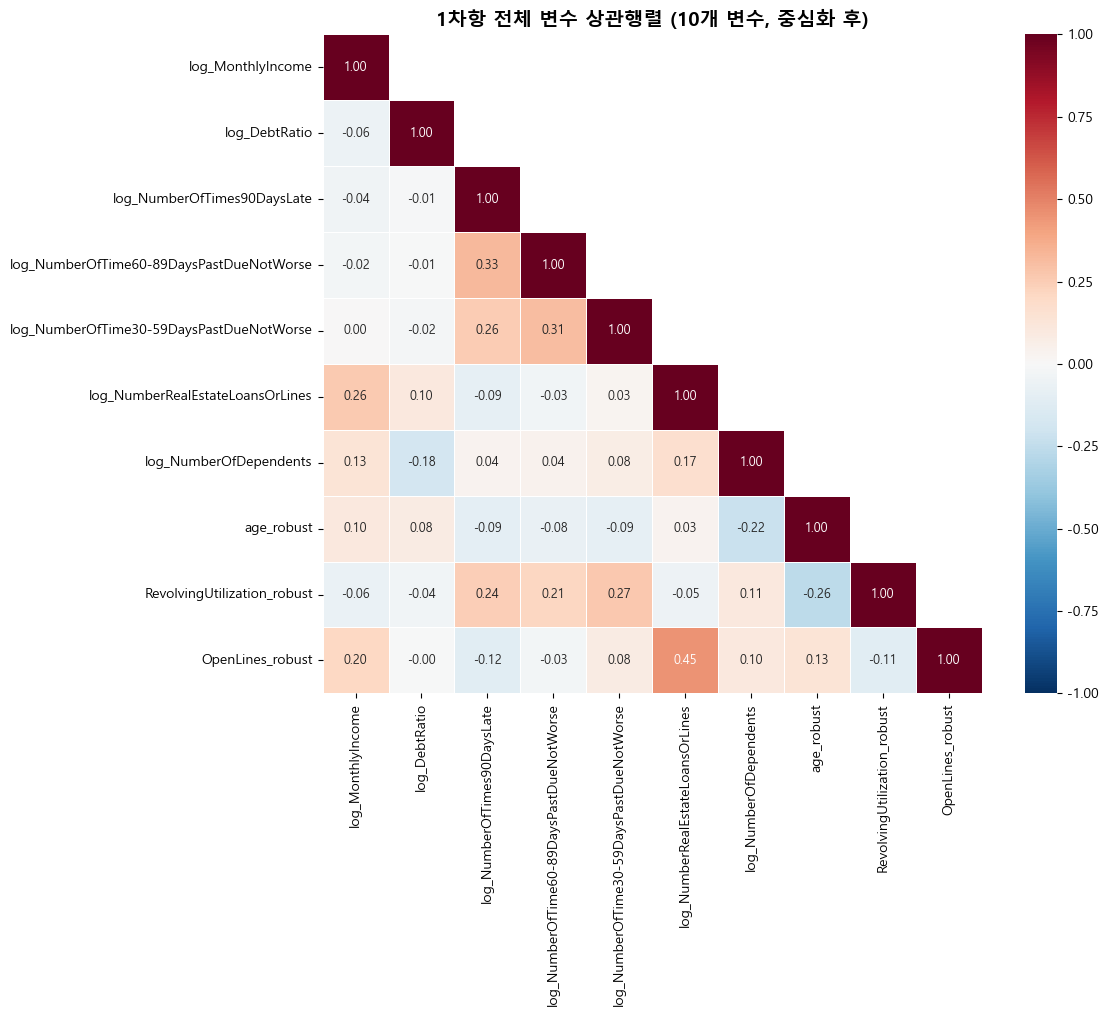


[높은 상관관계 (|r| > 0.5)]
  |r| > 0.5인 변수 쌍 없음

[2] 1차항 + 2차항 전체 변수 상관행렬 (중심화 후)
변수 수: 18개
  - 1차항: 10개
  - 2차항: 8개


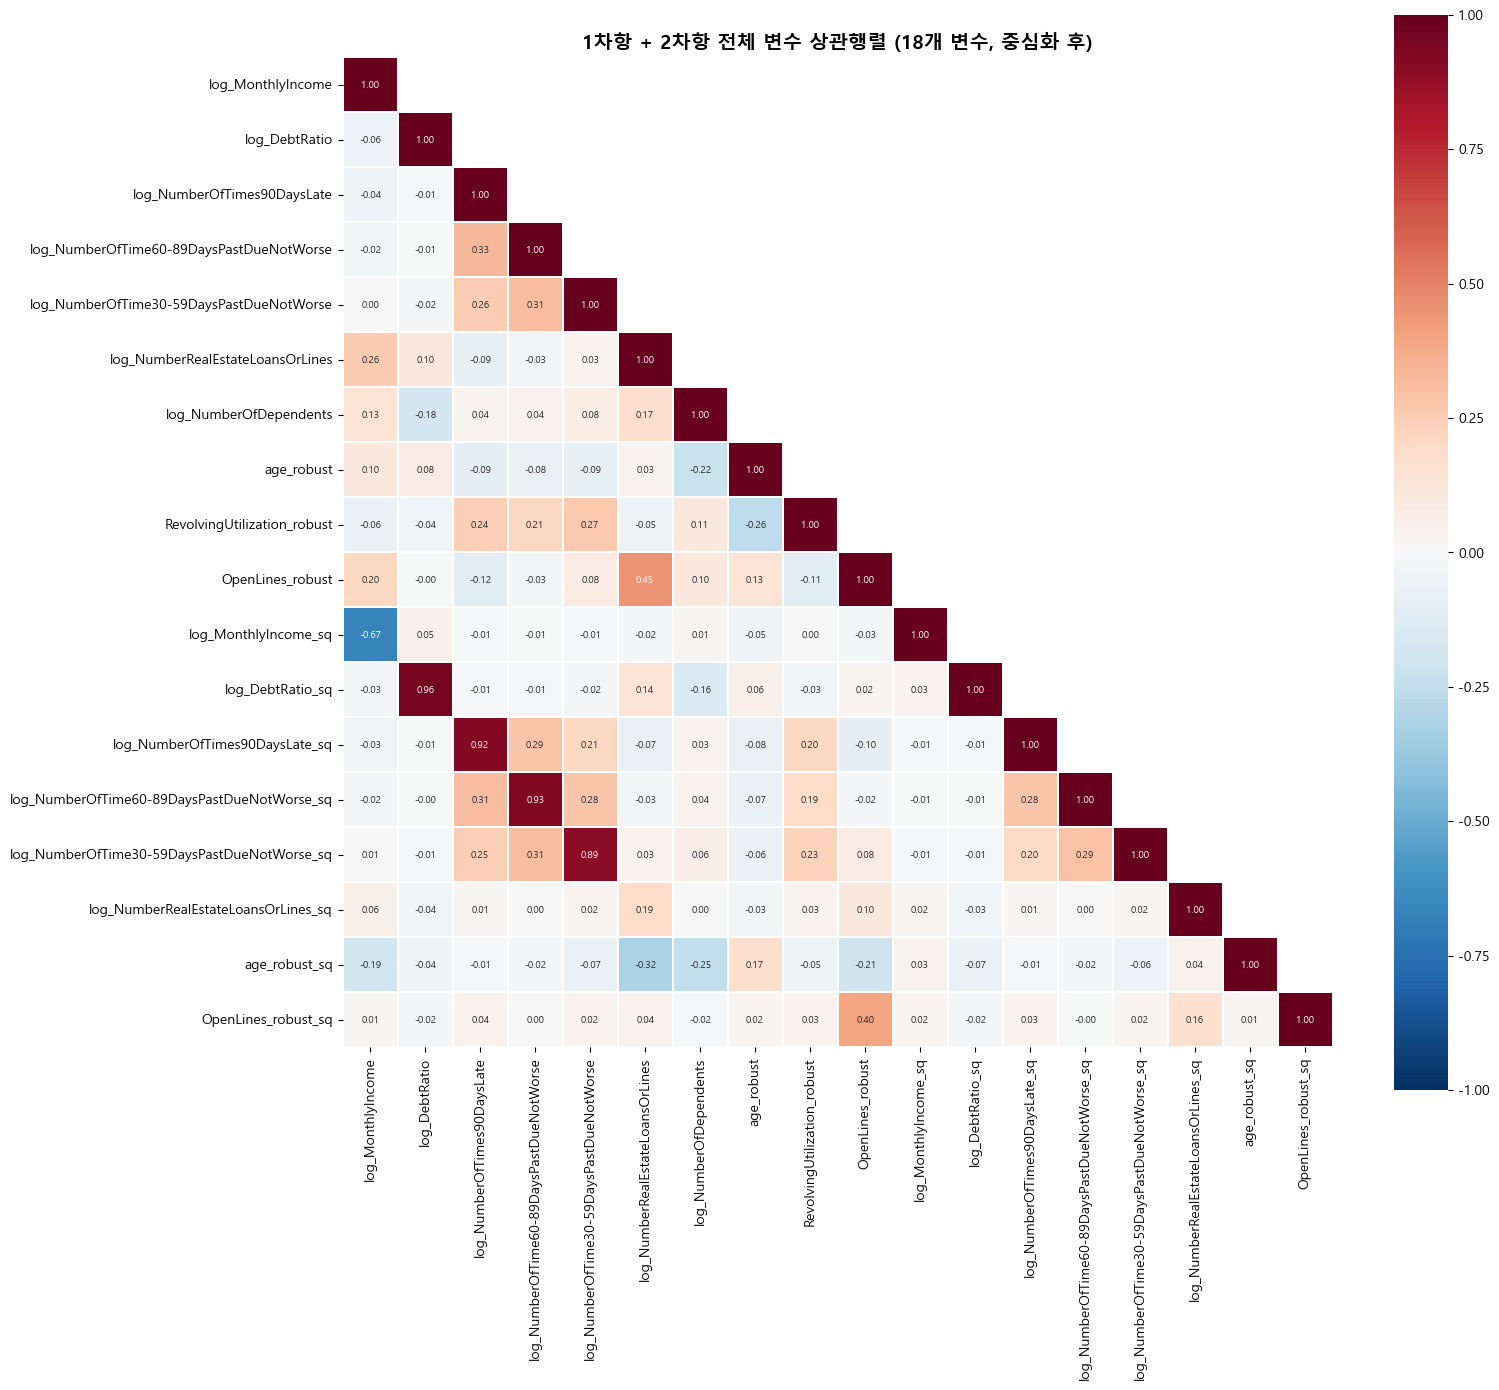


[높은 상관관계 (|r| > 0.7)]


,변수1,변수2,상관계수
0,log_DebtRatio,log_DebtRatio_sq,0.959
2,log_NumberOfTime60-89DaysPastDueNotWorse,log_NumberOfTime60-89DaysPastDueNotWorse_sq,0.929
1,log_NumberOfTimes90DaysLate,log_NumberOfTimes90DaysLate_sq,0.916
3,log_NumberOfTime30-59DaysPastDueNotWorse,log_NumberOfTime30-59DaysPastDueNotWorse_sq,0.893



[3] 선택된 변수 상관행렬 (중심화 후)
변수 수: 17개
  - 1차항: 9개
  - 2차항: 8개


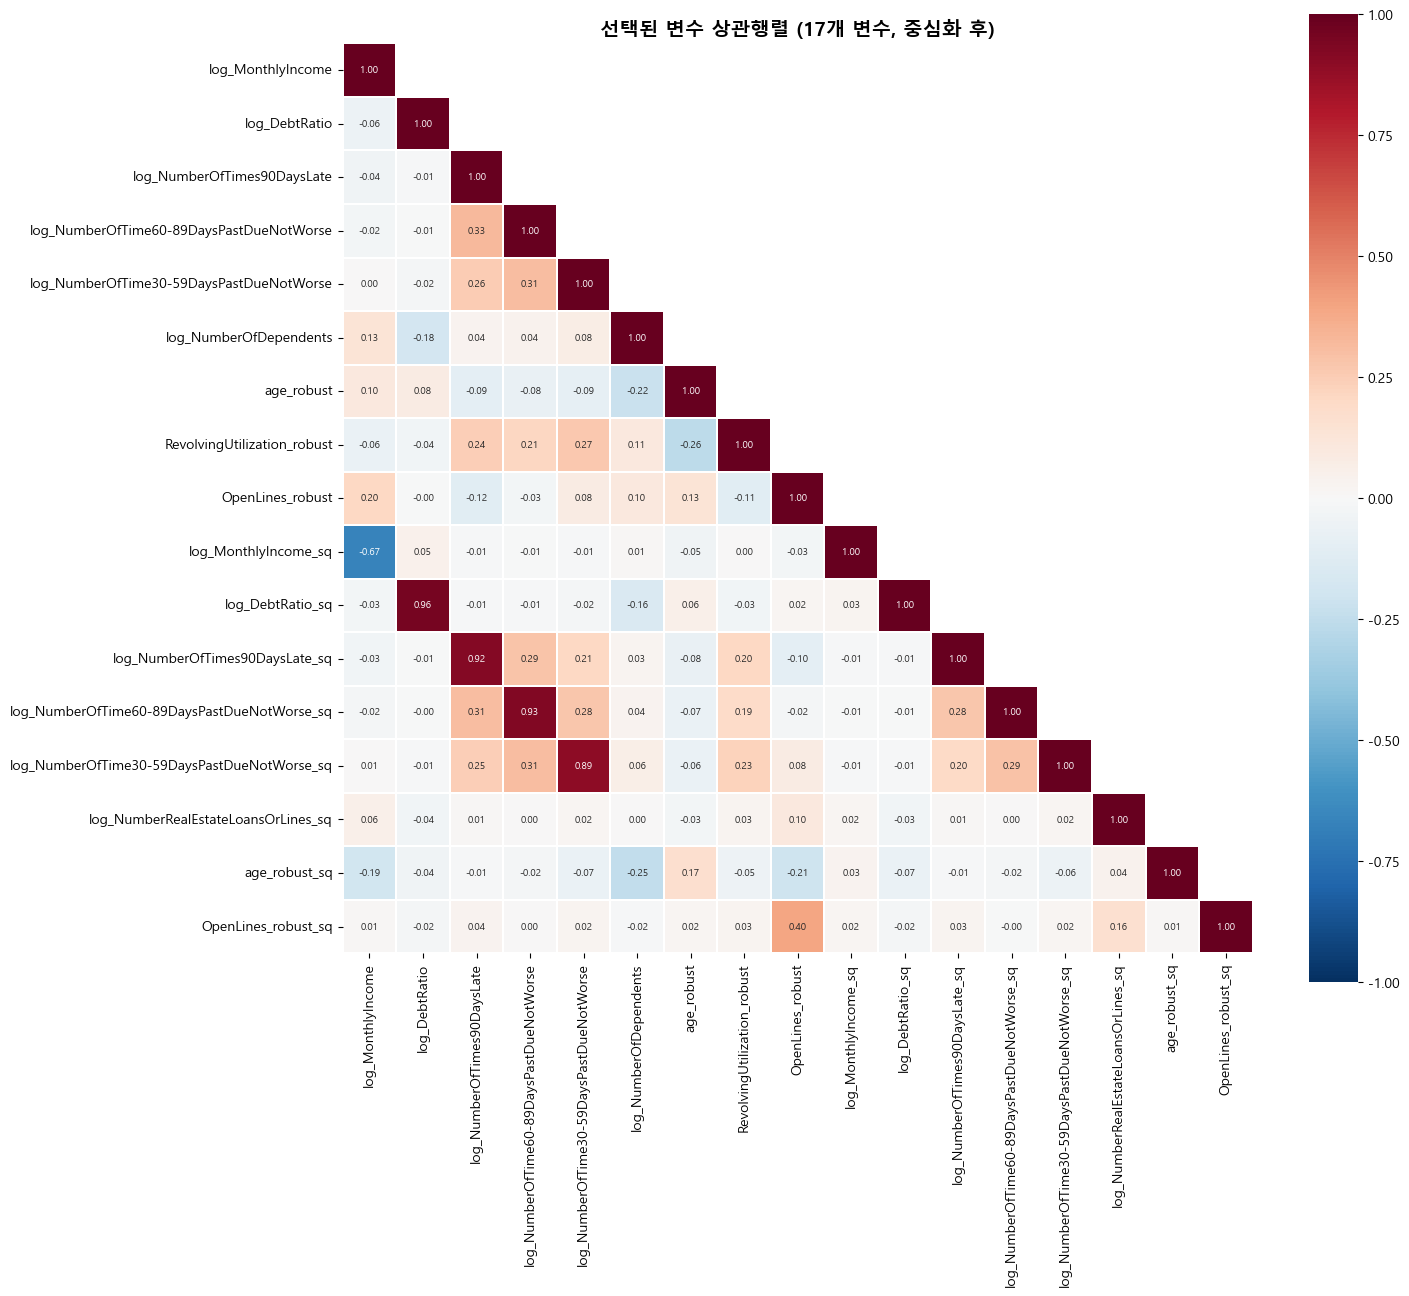


[높은 상관관계 (|r| > 0.7)]


,변수1,변수2,상관계수
0,log_DebtRatio,log_DebtRatio_sq,0.959
2,log_NumberOfTime60-89DaysPastDueNotWorse,log_NumberOfTime60-89DaysPastDueNotWorse_sq,0.929
1,log_NumberOfTimes90DaysLate,log_NumberOfTimes90DaysLate_sq,0.916
3,log_NumberOfTime30-59DaysPastDueNotWorse,log_NumberOfTime30-59DaysPastDueNotWorse_sq,0.893



[요약] 상관행렬 비교


,데이터셋,변수 수,|r|>0.5 쌍,|r|>0.7 쌍,|r|>0.9 쌍,평균 |r|
0,1차항 전체,10,0,0,0,0.120
1,1차항+2차항 전체,18,5,4,3,0.113
2,선택된 변수,17,5,4,3,0.112



💡 해석:
   - 평균 중심화 적용으로 1차항과 2차항 간 상관관계가 감소함
   - 변수 선택 후에도 높은 상관관계 쌍이 적어 다중공선성 우려 낮음


In [23]:
# ====================================================================
# 상관행렬 분석: 1차항 전체, 1차항+2차항 전체, 선택된 변수
# ====================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================================
# 1. 1차항만 있는 전체 변수 (10개)
# ====================================================================
print("=" * 80)
print("[1] 1차항 전체 변수 상관행렬 (중심화 후)")
print("=" * 80)

# 1차항 변수 목록 (df_clean의 모든 변수)
first_order_all = [col for col in df_clean.columns if col != TARGET_COL]
print(f"변수 수: {len(first_order_all)}개")
print(f"변수: {first_order_all}")

# 상관행렬 계산 (중심화 후 데이터 사용)
corr_first_order = df_clean_all[first_order_all].corr()

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_first_order, dtype=bool), k=1)
sns.heatmap(corr_first_order, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('1차항 전체 변수 상관행렬 (10개 변수, 중심화 후)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 높은 상관관계 출력
print("\n[높은 상관관계 (|r| > 0.5)]")
high_corr_pairs = []
for i in range(len(corr_first_order.columns)):
    for j in range(i+1, len(corr_first_order.columns)):
        if abs(corr_first_order.iloc[i, j]) > 0.5:
            high_corr_pairs.append({
                '변수1': corr_first_order.columns[i],
                '변수2': corr_first_order.columns[j],
                '상관계수': corr_first_order.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('상관계수', key=abs, ascending=False)
    display(high_corr_df)
else:
    print("  |r| > 0.5인 변수 쌍 없음")

# ====================================================================
# 2. 1차항 + 2차항 전체 변수 (18개)
# ====================================================================
print("\n" + "=" * 80)
print("[2] 1차항 + 2차항 전체 변수 상관행렬 (중심화 후)")
print("=" * 80)

# 전체 변수 (feature_pool)
print(f"변수 수: {len(feature_pool)}개")
print(f"  - 1차항: {len(first_order_all)}개")
print(f"  - 2차항: {len(feature_pool) - len(first_order_all)}개")

# 상관행렬 계산
corr_all = df_clean_all[feature_pool].corr()

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_all, dtype=bool), k=1)
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=0.3, ax=ax,
            annot_kws={'size': 7})
ax.set_title('1차항 + 2차항 전체 변수 상관행렬 (18개 변수, 중심화 후)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 높은 상관관계 출력 (1차항-2차항 쌍 포함)
print("\n[높은 상관관계 (|r| > 0.7)]")
high_corr_pairs_all = []
for i in range(len(corr_all.columns)):
    for j in range(i+1, len(corr_all.columns)):
        if abs(corr_all.iloc[i, j]) > 0.7:
            high_corr_pairs_all.append({
                '변수1': corr_all.columns[i],
                '변수2': corr_all.columns[j],
                '상관계수': round(corr_all.iloc[i, j], 3)
            })

if high_corr_pairs_all:
    high_corr_all_df = pd.DataFrame(high_corr_pairs_all).sort_values('상관계수', key=abs, ascending=False)
    display(high_corr_all_df)
else:
    print("  |r| > 0.7인 변수 쌍 없음")

# ====================================================================
# 3. 선택된 변수 (17개)
# ====================================================================
print("\n" + "=" * 80)
print("[3] 선택된 변수 상관행렬 (중심화 후)")
print("=" * 80)

print(f"변수 수: {len(selected_features)}개")
print(f"  - 1차항: {len(selected_linear)}개")
print(f"  - 2차항: {len(selected_quadratic)}개")

# 상관행렬 계산
corr_selected = X_selected.corr()

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(15, 13))
mask = np.triu(np.ones_like(corr_selected, dtype=bool), k=1)
sns.heatmap(corr_selected, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=0.3, ax=ax,
            annot_kws={'size': 7})
ax.set_title('선택된 변수 상관행렬 (17개 변수, 중심화 후)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 높은 상관관계 출력
print("\n[높은 상관관계 (|r| > 0.7)]")
high_corr_pairs_selected = []
for i in range(len(corr_selected.columns)):
    for j in range(i+1, len(corr_selected.columns)):
        if abs(corr_selected.iloc[i, j]) > 0.7:
            high_corr_pairs_selected.append({
                '변수1': corr_selected.columns[i],
                '변수2': corr_selected.columns[j],
                '상관계수': round(corr_selected.iloc[i, j], 3)
            })

if high_corr_pairs_selected:
    high_corr_selected_df = pd.DataFrame(high_corr_pairs_selected).sort_values('상관계수', key=abs, ascending=False)
    display(high_corr_selected_df)
else:
    print("  |r| > 0.7인 변수 쌍 없음")

# ====================================================================
# 4. 요약 비교
# ====================================================================
print("\n" + "=" * 80)
print("[요약] 상관행렬 비교")
print("=" * 80)

def count_high_corr(corr_matrix, threshold):
    """높은 상관관계 쌍 개수 계산"""
    count = 0
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                count += 1
    return count

summary_data = {
    '데이터셋': ['1차항 전체', '1차항+2차항 전체', '선택된 변수'],
    '변수 수': [len(first_order_all), len(feature_pool), len(selected_features)],
    '|r|>0.5 쌍': [count_high_corr(corr_first_order, 0.5), 
                   count_high_corr(corr_all, 0.5), 
                   count_high_corr(corr_selected, 0.5)],
    '|r|>0.7 쌍': [count_high_corr(corr_first_order, 0.7), 
                   count_high_corr(corr_all, 0.7), 
                   count_high_corr(corr_selected, 0.7)],
    '|r|>0.9 쌍': [count_high_corr(corr_first_order, 0.9), 
                   count_high_corr(corr_all, 0.9), 
                   count_high_corr(corr_selected, 0.9)],
    '평균 |r|': [np.mean(np.abs(corr_first_order.values[np.triu_indices(len(corr_first_order), k=1)])),
                np.mean(np.abs(corr_all.values[np.triu_indices(len(corr_all), k=1)])),
                np.mean(np.abs(corr_selected.values[np.triu_indices(len(corr_selected), k=1)]))]
}

summary_df = pd.DataFrame(summary_data)
summary_df['평균 |r|'] = summary_df['평균 |r|'].apply(lambda x: f"{x:.3f}")
display(summary_df)

print("\n💡 해석:")
print("   - 평균 중심화 적용으로 1차항과 2차항 간 상관관계가 감소함")
print("   - 변수 선택 후에도 높은 상관관계 쌍이 적어 다중공선성 우려 낮음")